In [74]:
import sys
sys.path.insert(0, '/code/src')

import pandas as pd 
import numpy as np
from datetime import datetime, date
import seaborn as sns
import pynwb
from matplotlib import pyplot as plt
import time
from tqdm.auto import tqdm

import importlib
import module
importlib.reload(module)
from module import decode_trial_identity

from sklearn.svm import LinearSVC
from sklearn import svm
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import confusion_matrix

In [75]:
# ---------------------------------------------------------------------------
# Shared colour scheme (teal / orange / purple) used by every figure below.
# Change these three hex values to restyle the whole notebook at once.
import matplotlib as mpl

C_TEAL   = "#48A69C"
C_ORANGE = "#E78C3B"
C_PURPLE = "#7D57C1"
C_GREY   = "#333333"

# task-context block -> colour (aud = purple, vis = teal)
BLOCK_PAL = {'aud': C_PURPLE, 'vis': C_TEAL}
BLOCK_ORDER = ['aud', 'vis']

# feature-importance groups in the error-vs-stim comparison
GROUP_PAL = {'error_exclusive': C_ORANGE, 'stim_exclusive': C_TEAL,
             'shared': C_PURPLE, 'other': '0.8'}

# white -> purple sequential map for heatmaps (confusion matrices)
SEQ_CMAP = mpl.colors.LinearSegmentedColormap.from_list(
    'seq_purple', ['#ffffff', C_PURPLE])

# default line / marker colour cycle
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=[C_TEAL, C_ORANGE, C_PURPLE])


In [76]:
from aind_data_access_api.document_db import MetadataDbClient

API_GATEWAY_HOST = "api.allenneuraldynamics.org"
DATABASE = 'metadata_index'
COLLECTION = 'data_assets'

docdb_api_client = MetadataDbClient(
   host=API_GATEWAY_HOST,
    version="v2",
   database=DATABASE,
   collection=COLLECTION,
)
print(docdb_api_client._base_url)

https://api.allenneuraldynamics.org/v2/metadata_index/data_assets


In [77]:
aggregate = [
  {
    "$match": {
      "data_description.project_name": "Dynamic Routing", 
      "data_description.data_level": "derived", 
      "processing.data_processes": {
        "$elemMatch": {
          "process_type": "File format conversion",
          "start_date_time": {"$regex": "^2026-08-04"}
        }
      }
    }
  },
  {
    "$project": {
      "name": 1, 
      "subject_id": "$data_description.subject_id",
      "genotype": "$subject.subject_details.genotype", 
      "date_of_birth": "$subject.subject_details.date_of_birth", 
      "sex": "$subject.subject_details.sex",  
      "session_start_time": "$acquisition.acquisition_start_time",
      "session_end_time": "$acquisition.acquisition_end_time", 
      "stimulus_epochs": "$acquisition.stimulus_epochs",
      "project_name": "$data_description.project_name", 
      "modality": "$data_description.modalities.name", 
      "targeted_structure": "$acquisition.data_streams.configurations.probes.primary_targeted_structure.name" 
    }
  },
]
    
records = docdb_api_client.aggregate_docdb_records(pipeline=aggregate)

# Extract performance metrics in Python
for r in records:
    dr = next((e for e in r.get("stimulus_epochs", []) if e.get("stimulus_name") == "DynamicRouting1"), None)
    r["dr_performance"] = dr["performance_metrics"] if dr else None

In [78]:
df = pd.DataFrame(records)
df['session_date'] = df.apply(lambda x: datetime.fromisoformat(x['session_start_time']).date(), axis=1)
df['session_start_time'] = df.apply(lambda x: datetime.fromisoformat(x['session_start_time']).time(), axis=1)
df['session_end_time'] = df.apply(lambda x: datetime.fromisoformat(x['session_end_time']).time(), axis=1)
df['date_of_birth'] = df.apply(lambda x: datetime.strptime(x['date_of_birth'], '%Y-%m-%d').date(), axis=1)
df['age'] = df.apply(lambda x: (x['session_date'] - x['date_of_birth']).days, axis=1)

df['trials_total'] = df['dr_performance'].apply(lambda x: x['trials_total'] if x else None)
df['trials_rewarded'] = df['dr_performance'].apply(lambda x: x['trials_rewarded'] if x else None)
df['reward_rate'] = df['trials_rewarded'] / df['trials_total']
df['reward_consumed_mL'] = df['dr_performance'].apply(lambda x: x['reward_consumed_during_epoch'] if x else None)
df['block_metrics'] = df['dr_performance'].apply(lambda x: x['output_parameters']['block_metrics'] if x else None)
df['mean_dprime_same_modal'] = df['block_metrics'].apply(
    lambda x: pd.Series([b['dprime_same_modal'] for b in x.values()]).mean() if x else None
)
df['mean_dprime_other_modal'] = df['block_metrics'].apply(
    lambda x: pd.Series([b['dprime_other_modal_go'] for b in x.values()]).mean() if x else None
)

order = ['project_name', '_id', 'name', 'subject_id', 'genotype', 'date_of_birth', 'age', 'sex',
         'modality', 'session_date', 'session_start_time', 'session_end_time', 'targeted_structure',
         'trials_total', 'trials_rewarded', 'reward_rate', 'reward_consumed_mL',
         'mean_dprime_same_modal', 'mean_dprime_other_modal']
df = df[order].sort_values(by='subject_id')

In [79]:
# --- Pass 1: scan every mouse x region for the decoding criterion ----------
# Four decoders, each run within a single task block:
#
#   error decoder  -> block TARGET-stimulus HIT  vs  block DISTRACTOR FALSE ALARM
#                     aud block: sound1 hit  vs  vis1  false alarm
#                     vis block: vis1  hit  vs  sound1 false alarm
#                     (stimulus identity is confounded with the lick / error
#                      signal -- that is the point of the comparison below)
#
#   stim  decoder  -> sound2 vs vis2 on CORRECT-REJECT trials (licking correctly
#                     withheld), so it reads stimulus identity only and is not
#                     confounded by the lick / error signal
#
# Both decoders are run separately in the auditory block and in the visual
# block, giving four decoders total: error_aud, error_vis, stim_aud, stim_vis.
#
# A region-session qualifies for a decoder if it has >= MIN_UNITS QC units and
# >= MIN_TRIALS_PER_CLASS trials in each of that decoder's two classes.
#
# The datacube is a read-only FUSE mount, so an individual chunk read can fail
# with OSError (Errno 5) even though the path exists. Each session load is
# retried; a session whose data stays unreadable is skipped and recorded in
# `failed_sessions` instead of aborting the whole scan.

from module import get_stim_times, _BLOCK_STIM

MIN_UNITS = 50
MIN_TRIALS_PER_CLASS = 10
MIN_SESSIONS = 3          # keep regions meeting criterion in >= 3 sessions

N_LOAD_RETRIES = 1        # attempts per session before giving up on it
LOAD_RETRY_WAIT = 10      # seconds between attempts

# name -> (stim_a, outcome_a, stim_b, outcome_b, block)
DECODER_TRIALS = {
    'error_aud': ('sound1', 'is_hit',            'vis1',   'is_false_alarm',    'aud'),
    'error_vis': ('vis1',   'is_hit',            'sound1', 'is_false_alarm',    'vis'),
    'stim_aud':  ('sound2', 'is_correct_reject', 'vis2',   'is_correct_reject', 'aud'),
    'stim_vis':  ('sound2', 'is_correct_reject', 'vis2',   'is_correct_reject', 'vis'),
}


def load_session(nwb_path, n_retries=N_LOAD_RETRIES, wait=LOAD_RETRY_WAIT):
    """Read one session, retrying failed reads from the datacube mount.

    Returns (nwbfile, units_df, trials_df), or None if every attempt failed.
    Both tables are materialised here so that a chunk the mount cannot serve
    fails now, on a session we can skip, rather than later inside Pass 2.
    """
    for attempt in range(1, n_retries + 1):
        try:
            nwbfile = pynwb.read_nwb(nwb_path)
            return nwbfile, nwbfile.units.to_dataframe(), nwbfile.trials.to_dataframe()
        except OSError as err:
            tqdm.write(f"  read failed (attempt {attempt}/{n_retries}): {err}")
            if attempt < n_retries:
                time.sleep(wait)
    return None


nwb_cache = {}            # subject_id -> (nwbfile, units_df, trials_df), reused in Pass 2
failed_sessions = []      # sessions the mount would not serve
scan_rows = []
for _, m in tqdm(list(df.iterrows()), desc="scan", unit="mouse"):
    nwb_path = f"/data/dynamicrouting_datacube/{m['name']}/{m['name'][8:25]}.nwb.zarr"
    t0 = time.time()
    loaded = load_session(nwb_path)
    if loaded is None:
        failed_sessions.append(dict(mouse_id=m['subject_id'], name=m['name']))
        tqdm.write(f"{m['subject_id']}: SKIPPED -- unreadable after "
                   f"{N_LOAD_RETRIES} attempts ({time.time() - t0:.0f}s)")
        continue
    nwbfile, units, trials = loaded
    nwb_cache[m['subject_id']] = (nwbfile, units, trials)

    # trials per class for each decoder (block match is on by default)
    trial_counts = {}
    for name, (sa, oa, sb, ob, blk) in DECODER_TRIALS.items():
        na = int(get_stim_times(trials, sa, blk, oa).sum())
        nb = int(get_stim_times(trials, sb, blk, ob).sum())
        trial_counts[name] = (na, nb)

    unit_counts = units.loc[units.default_qc, 'structure'].value_counts()
    for region, n_units in unit_counts.items():
        units_ok = n_units >= MIN_UNITS
        row = dict(mouse_id=m['subject_id'], region=region, n_units=int(n_units))
        for name, (na, nb) in trial_counts.items():
            row[f'n_{name}_a'] = na
            row[f'n_{name}_b'] = nb
            row[f'meets_{name}'] = bool(units_ok
                                       and na >= MIN_TRIALS_PER_CLASS
                                       and nb >= MIN_TRIALS_PER_CLASS)
        scan_rows.append(row)
    tqdm.write(f"{m['subject_id']}: "
               + " | ".join(f"{k} {v[0]}/{v[1]}" for k, v in trial_counts.items())
               + f"  ({time.time() - t0:.0f}s to load)")

scan = pd.DataFrame(scan_rows)

if failed_sessions:
    print(f"\n!! {len(failed_sessions)} of {len(df)} sessions skipped as unreadable: "
          + ", ".join(f['mouse_id'] for f in failed_sessions))
print(f"scanned {scan.mouse_id.nunique()} sessions, "
      f"{scan.region.nunique()} distinct regions\n")

def _keep(col):
    counts = scan[scan[col]].groupby('region').mouse_id.nunique()
    return sorted(counts[counts >= MIN_SESSIONS].index)

# regions meeting each decoder's criterion in >= MIN_SESSIONS sessions
keep = {name: _keep(f'meets_{name}') for name in DECODER_TRIALS}
for name, regions in keep.items():
    print(f"{name:<10}: {len(regions):2d} regions in >= {MIN_SESSIONS} sessions: {regions}")


scan:   0%|          | 0/12 [00:00<?, ?mouse/s]/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (430361, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (430350, 500) float32 read-only>
  warnings.warn(
scan:   8%|▊         | 1/12 [00:48<08:53, 48.53s/mouse]

662892: error_aud 63/10 | error_vis 60/23 | stim_aud 33/37 | stim_vis 31/34  (49s to load)


/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (400638, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (400680, 500) float32 read-only>
  warnings.warn(
scan:  17%|█▋        | 2/12 [01:53<09:40, 58.09s/mouse]

664851: error_aud 69/14 | error_vis 70/16 | stim_aud 44/55 | stim_vis 51/55  (65s to load)


/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (439878, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (439866, 500) float32 read-only>
  warnings.warn(
scan:  25%|██▌       | 3/12 [02:28<07:06, 47.41s/mouse]

...

742903: error_aud 62/14 | error_vis 62/11 | stim_aud 42/45 | stim_vis 54/54  (68s to load)


/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (420563, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (420580, 500) float32 read-only>
  warnings.warn(
scan:  92%|█████████▏| 11/12 [10:50<01:03, 63.52s/mouse]

743199: error_aud 61/23 | error_vis 71/10 | stim_aud 9/45 | stim_vis 49/48  (63s to load)


/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (420648, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (420666, 500) float32 read-only>
  warnings.warn(
scan: 100%|██████████| 12/12 [11:52<00:00, 59.34s/mouse]

759434: error_aud 69/17 | error_vis 73/2 | stim_aud 40/58 | stim_vis 56/60  (62s to load)
scanned 12 sessions, 100 distinct regions

error_aud :  7 regions in >= 3 sessions: ['CP', 'MOp', 'MOs', 'ORBl', 'PL', 'SSp', 'SSs']
error_vis :  3 regions in >= 3 sessions: ['MOp', 'MOs', 'SSp']
stim_aud  :  6 regions in >= 3 sessions: ['CP', 'MOp', 'MOs', 'ORBl', 'SSp', 'SSs']
stim_vis  :  7 regions in >= 3 sessions: ['CP', 'MOp', 'MOs', 'ORBl', 'PL', 'SSp', 'SSs']


## Choosing the decoding window — trial-averaged population PSTH

Before decoding, look at the grand-average peri-stimulus firing of every
default-QC unit in every loaded session, aligned to stimulus onset and
averaged over all target trials. Each unit is baseline-subtracted (mean rate
in the 0.3 s before onset) so the sensory transient is not swamped by a few
high-rate units.

Overlaid are the mean **first-lick latency** (`trials.response_time` −
stimulus onset, over target trials with a response) and the mean **reward
latency** (`trials.reward_time` − stimulus onset, over rewarded trials), each
with a ±1 SD band across trials pooled over sessions.

The shaded band is the current decoding window (`DECODE_WINDOW_S`). Move it so
it sits **after the main sensory response but before the first licks / reward**,
then re-run Pass 2 — `DECODE_BIN_EDGES` / `WINDOW_BIN_SLICE` defined here are
what Pass 2 (and the pooled decoder) use.

In [80]:
# Trial-averaged population PSTH + behavioural event times -> pick the window.
from module import get_binned_triggered_spike_counts_fast

# --- decoding window, shared by Pass 2 and the pooled decoder -------------
DECODE_BIN_EDGES = np.arange(-0.3, 2.0, 0.1)      # 100 ms bins, relative to onset
DECODE_WINDOW_S = (0.2, 0.4)                      # <-- decoding window (default 0.2 - 0.4 s from onset); tune from the plot
_lo = int(np.argmin(np.abs(DECODE_BIN_EDGES - DECODE_WINDOW_S[0])))
_hi = int(np.argmin(np.abs(DECODE_BIN_EDGES - DECODE_WINDOW_S[1])))
WINDOW_BIN_SLICE = slice(_lo, _hi)
print(f"decode window {DECODE_WINDOW_S[0]:.2f}-{DECODE_WINDOW_S[1]:.2f} s "
      f"-> bins {WINDOW_BIN_SLICE.start}:{WINDOW_BIN_SLICE.stop}")

# --- PSTH settings ------------------------------------------------------
PSTH_EDGES = np.arange(-0.5, 1.5 + 1e-9, 0.02)    # 20 ms bins for the display
PSTH_CENTERS = PSTH_EDGES[:-1] + np.diff(PSTH_EDGES) / 2
BASELINE_S = (-0.2, 0.0)
_base_mask = (PSTH_CENTERS >= BASELINE_S[0]) & (PSTH_CENTERS < BASELINE_S[1])

unit_psth_rows = []          # baseline-subtracted rate, one row per QC unit
lick_latency_all, reward_latency_all = [], []
for subject_id, (_nwb, units_s, trials_s) in nwb_cache.items():
    onset = trials_s.stim_start_time.to_numpy()
    is_tgt = trials_s.is_target.to_numpy()
    tgt_onset = onset[is_tgt]
    qc = units_s[units_s.default_qc]
    for spike_times in qc.spike_times.values:
        counts = get_binned_triggered_spike_counts_fast(
            spike_times, tgt_onset, PSTH_EDGES)
        rate = counts.mean(axis=0) / np.diff(PSTH_EDGES)
        unit_psth_rows.append(rate - rate[_base_mask].mean())

    lick = trials_s.response_time.to_numpy() - onset
    lick_latency_all.append(lick[is_tgt & trials_s.is_response.to_numpy()
                                 & np.isfinite(lick)])
    rew = trials_s.reward_time.to_numpy() - onset
    reward_latency_all.append(rew[trials_s.is_rewarded.to_numpy() & np.isfinite(rew)])

psth_mat = np.vstack(unit_psth_rows)
grand = psth_mat.mean(axis=0)
grand_sem = psth_mat.std(axis=0, ddof=1) / np.sqrt(psth_mat.shape[0])
lat_lick = np.concatenate(lick_latency_all)
lat_reward = np.concatenate(reward_latency_all)


decode window 0.20-0.40 s -> bins 5:7


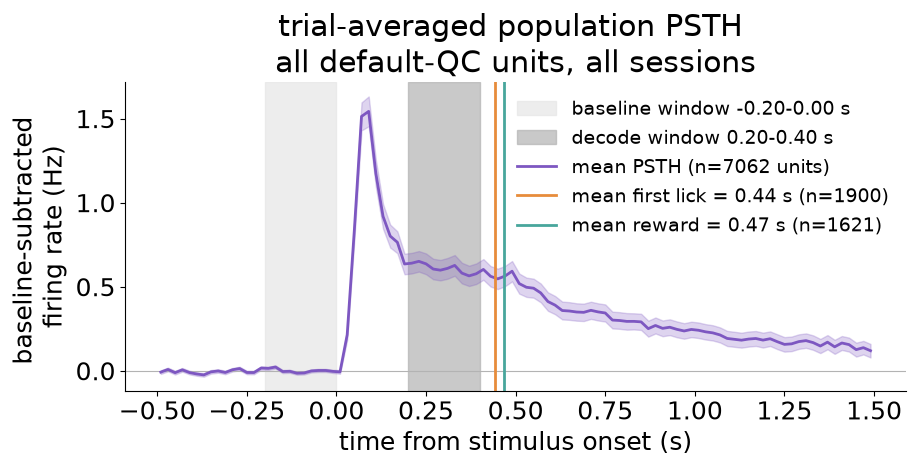

In [81]:
# Plot PSTH
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.axhline(0, color='0.7', lw=0.8)
ax.axvspan(*BASELINE_S, color='0.9', alpha=0.7, zorder=0,
           label=f'baseline window {BASELINE_S[0]:.2f}-{BASELINE_S[1]:.2f} s')
ax.axvspan(*DECODE_WINDOW_S, color='0.7', alpha=0.7, zorder=0,
           label=f'decode window {DECODE_WINDOW_S[0]:.2f}-{DECODE_WINDOW_S[1]:.2f} s')
ax.fill_between(PSTH_CENTERS, grand - grand_sem, grand + grand_sem,
                color=C_PURPLE, alpha=0.25)
ax.plot(PSTH_CENTERS, grand, color=C_PURPLE, lw=2,
        label=f'mean PSTH (n={psth_mat.shape[0]} units)')
for lat, colour, lab in [(lat_lick, C_ORANGE, 'first lick'),
                         (lat_reward, C_TEAL, 'reward')]:
    m = np.nanmean(lat)
    ax.axvline(m, color=colour, lw=2, label=f'mean {lab} = {m:.2f} s (n={lat.size})')
ax.set_xlabel('time from stimulus onset (s)')
ax.set_ylabel('baseline-subtracted \nfiring rate (Hz)')
ax.set_title('trial-averaged population PSTH \nall default-QC units, all sessions')
ax.legend(frameon=False, fontsize=14)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

In [82]:
# --- Pass 2: run all four decoders on their kept region-sessions ----------
# Reuses the nwbfiles cached in Pass 1. Each region-session is decoded with a
# 50-unit / 10-trial-per-class subsample so feature count and sample count are
# matched across regions, blocks and decoders.
#
# chance is estimated empirically per region-session (label shuffle, N_PERM
# permutations of the same cross-validation). Feature importance comes from
# N_IMPORTANCE_REPEATS independent stratified train/test splits.
N_PERM = 200
N_IMPORTANCE_REPEATS = 100
IMPORTANCE_TOP_FRAC = 0.10     # flag the top 10% of neurons by |w_r| each repeat

DECODERS = {
    'error_aud': dict(family='error', block='aud',
                      kwargs=dict(block='aud', outcome_filter=1, match_block=True)),
    'error_vis': dict(family='error', block='vis',
                      kwargs=dict(block='vis', outcome_filter=1, match_block=True)),
    'stim_aud':  dict(family='stim', block='aud',
                      kwargs=dict(block='aud', stim_pair=('sound2', 'vis2'),
                                  class_outcomes=('is_correct_reject', 'is_correct_reject'),
                                  match_block=True)),
    'stim_vis':  dict(family='stim', block='vis',
                      kwargs=dict(block='vis', stim_pair=('sound2', 'vis2'),
                                  class_outcomes=('is_correct_reject', 'is_correct_reject'),
                                  match_block=True)),
}

rows = []
for name, spec in DECODERS.items():
    todo = scan[scan[f'meets_{name}'] & scan.region.isin(keep[name])]
    print(f"[{name}] decoding {len(todo)} region-sessions "
          f"({todo.mouse_id.nunique()} mice, {todo.region.nunique()} regions)")
    for subject_id, grp in tqdm(todo.groupby('mouse_id'), desc=name, unit="mouse"):
        nwbfile, _, _ = nwb_cache[subject_id]
        for region in tqdm(sorted(grp.region), desc=f"{subject_id}",
                           unit="region", leave=False):
            r = decode_trial_identity(
                nwbfile, region,
                decode_bin_edge_array=DECODE_BIN_EDGES,
                window_bin_slice=WINDOW_BIN_SLICE,  # set from the PSTH cell (DECODE_WINDOW_S)
                n_neurons=50, n_trials=10,
                min_units=MIN_UNITS, min_trials_per_class=MIN_TRIALS_PER_CLASS,
                n_permutations=N_PERM,
                n_importance_repeats=N_IMPORTANCE_REPEATS,
                importance_top_frac=IMPORTANCE_TOP_FRAC,
                mouse_id=subject_id,
                **spec['kwargs'])
            r['decoder'] = name
            r['family'] = spec['family']
            rows.append(r)
            msg = f"  {name:<10} {region:<8} {r['status']:<6}"
            if r['cv_accuracy_mean'] is not None:
                msg += (f" cv {r['cv_accuracy_mean']:.2f}  "
                        f"(chance {r['chance']:.2f} +/- {r['chance_std']:.2f}, "
                        f"p {r['chance_p']:.3f})")
            tqdm.write(msg)

results = pd.DataFrame(rows)
ok_all = results[results.status == 'ok'].copy()
print("\ndone: " + ", ".join(
    f"{n} {int((ok_all.decoder == n).sum())}" for n in DECODERS))


[error_aud] decoding 26 region-sessions (9 mice, 7 regions)


error_aud:  11%|█         | 1/9 [00:43<05:44, 43.03s/mouse]

  error_aud  ORBl     ok     cv 0.70  (chance 0.53 +/- 0.12, p 0.134)



error_aud:  11%|█         | 1/9 [01:40<05:44, 43.03s/mouse]

  error_aud  MOs      ok     cv 0.85  (chance 0.50 +/- 0.13, p 0.015)


...

  stim_vis   CP       ok     cv 0.40  (chance 0.49 +/- 0.13, p 0.816)



stim_vis:  91%|█████████ | 10/11 [10:05<01:04, 64.18s/mouse]

  stim_vis   MOs      ok     cv 0.45  (chance 0.49 +/- 0.14, p 0.677)



stim_vis: 100%|██████████| 11/11 [10:13<00:00, 55.79s/mouse]

  stim_vis   SSp      ok     cv 0.60  (chance 0.48 +/- 0.12, p 0.249)

done: error_aud 26, error_vis 11, stim_aud 27, stim_vis 32


## Decoding accuracy by region — auditory vs visual block

Four decoders are run, each within a single task block:

| decoder | classes | reads |
|---|---|---|
| `error_aud` | sound1 hit vs vis1 false alarm (aud block) | stimulus identity **+** lick / error signal |
| `error_vis` | vis1 hit vs sound1 false alarm (vis block) | stimulus identity **+** lick / error signal |
| `stim_aud` | sound2 vs vis2, correct-reject trials (aud block) | stimulus identity only (lick withheld) |
| `stim_vis` | sound2 vs vis2, correct-reject trials (vis block) | stimulus identity only (lick withheld) |

Pass 1 scans every mouse × region and keeps, per decoder, only regions that
meet the criterion (`>= MIN_UNITS` QC units and `>= MIN_TRIALS_PER_CLASS`
trials in each class) in at least `MIN_SESSIONS` sessions. Pass 2 runs each
decoder only on its kept region-sessions.

The metric is the cross-validated accuracy (`cv_accuracy_mean`). `chance` is
estimated empirically per region-session: the class labels are shuffled
`N_PERM` times and the same cross-validation is re-run on each shuffle, so
`chance` is the mean of that null distribution (`chance_std` its SD,
`chance_p` the permutation p-value). Because classes are subsampled to be
balanced this sits near 0.5 but carries a real spread and significance test.

The figures below put the auditory and visual block side by side for each
decoder family, so the block comparison is direct. Feature importance (which
neurons carry each decoder) is handled further down.

In [83]:
# Per-region summary across sessions / mice, split by block, for each decoder
# family. Region filtering (>= MIN_SESSIONS qualifying sessions) already
# happened in Pass 1.
acc_col = 'cv_accuracy_mean'

plot_df = ok_all.dropna(subset=[acc_col]).copy()
plot_df['acc_above_chance'] = plot_df[acc_col] - plot_df['chance']

def _sem(x):
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0

def region_summary(family):
    d = plot_df[plot_df.family == family]
    return (d.groupby(['region', 'block'])
            .agg(mean_acc=(acc_col, 'mean'),
                 sem_acc=(acc_col, _sem),
                 mean_above_chance=('acc_above_chance', 'mean'),
                 sem_above_chance=('acc_above_chance', _sem),
                 mean_chance=('chance', 'mean'),
                 mean_chance_p=('chance_p', 'mean'),
                 n_sessions=(acc_col, 'size'),
                 n_mice=('mouse_id', 'nunique'))
            .reset_index()
            .sort_values(['block', 'mean_acc'], ascending=[True, False]))

error_summary = region_summary('error')
stim_summary = region_summary('stim')
assert (error_summary.n_sessions >= MIN_SESSIONS).all()
assert (stim_summary.n_sessions >= MIN_SESSIONS).all()
error_summary


,region,block,mean_acc,sem_acc,mean_above_chance,sem_above_chance,mean_chance,mean_chance_p,n_sessions,n_mice
6,PL,aud,0.866667,0.088192,0.364167,0.092394,0.502500,0.043118,3,3
3,MOs,aud,0.807143,0.029738,0.307750,0.025783,0.499393,0.034115,7,7
0,CP,aud,0.783333,0.033333,0.279250,0.029626,0.504083,0.039801,3,3
7,SSp,aud,0.775000,0.043301,0.287875,0.040301,0.487125,0.047264,4,4
5,ORBl,aud,0.733333,0.016667,0.225417,0.026928,0.507917,0.091211,3,3
9,SSs,aud,0.733333,0.016667,0.244333,0.007145,0.489000,0.054726,3,3
1,MOp,aud,0.716667,0.072648,0.227500,0.084885,0.489167,0.132670,3,3
4,MOs,vis,0.880000,0.051478,0.389800,0.056903,0.490200,0.030846,5,5
2,MOp,vis,0.716667,0.116667,0.206167,0.122834,0.510500,0.222222,3,3
8,SSp,vis,0.550000,0.115470,0.049167,0.116569,0.500833,0.456053,3,3


/tmp/ipykernel_784/1484636904.py:35: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:0.2'` for the same effect.

  sns.stripplot(data=d, x='region', y=acc_col, hue='block', order=order,
/tmp/ipykernel_784/1484636904.py:35: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:0.2'` for the same effect.

  sns.stripplot(data=d, x='region', y=acc_col, hue='block', order=order,


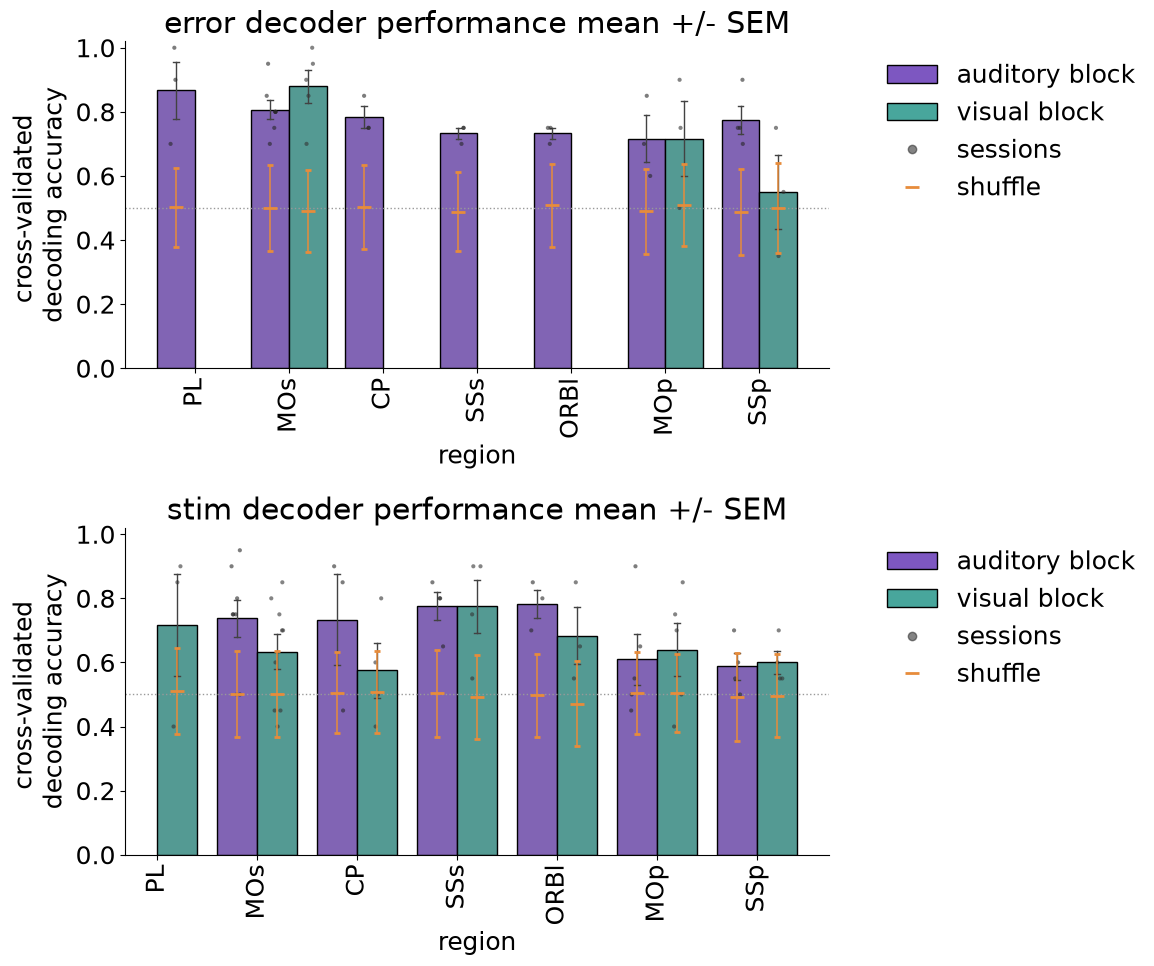

In [84]:
# Mean decoding accuracy per region, auditory vs visual block (mean +/- SEM
# across sessions, with individual session points). One row per decoder family.
# BLOCK_PAL / BLOCK_ORDER come from the shared colour-scheme cell.
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.rcParams.update({'font.size': 18})
fig, axes = plt.subplots(2, 1, figsize=(max(12, 1 * plot_df.region.nunique()), 10))

BLOCK_LABEL = {'aud': 'auditory block', 'vis': 'visual block'}
legend_handles = (
    [Patch(facecolor=BLOCK_PAL[b], edgecolor='black', label=BLOCK_LABEL[b])
     for b in BLOCK_ORDER]
    + [Line2D([0], [0], marker='o', linestyle='none', markerfacecolor='0.2',
              markeredgecolor='0.2', markersize=6, alpha=0.6, label='sessions'),
       Line2D([0], [0], marker='_', linestyle='none', color=C_ORANGE,
              markersize=10, markeredgewidth=2, label='shuffle')])

for ax, family in zip(axes, ['error', 'stim']):
    d = plot_df[plot_df.family == family]
    if family == 'error':
        order = (d.groupby('region')[acc_col].mean()
                 .sort_values(ascending=False).index.tolist())
        error_order = order
    else:
        # same region order as the error decoder plot; any regions specific to
        # the stim decoder are appended in mean-accuracy order
        stim_only = (d[~d.region.isin(error_order)].groupby('region')[acc_col]
                     .mean().sort_values(ascending=False).index.tolist())
        order = error_order + stim_only

    sns.barplot(data=d, x='region', y=acc_col, hue='block', order=order,
                hue_order=BLOCK_ORDER, palette=BLOCK_PAL, edgecolor='black',
                errorbar='se', capsize=0.12, err_kws={'linewidth': 1.0}, ax=ax)
    sns.stripplot(data=d, x='region', y=acc_col, hue='block', order=order,
                  hue_order=BLOCK_ORDER, dodge=True, color='0.2', size=3,
                  jitter=0.12, alpha=0.6, legend=False, ax=ax)

    # per-region, per-block shuffle chance (mean +/- SD of the null), placed on
    # the dodged bar centres
    for xi, region in enumerate(order):
        for sign, blk in zip((-0.2, 0.2), BLOCK_ORDER):
            sub = d[(d.region == region) & (d.block == blk)]
            if len(sub):
                ax.errorbar(xi + sign, sub['chance'].mean(),
                            yerr=sub['chance_std'].mean(), fmt='_', color=C_ORANGE,
                            markersize=10, markeredgewidth=2, elinewidth=1.1,
                            capsize=2, zorder=5)

    ax.axhline(0.5, ls=':', color='0.6', linewidth=1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel('region')
    ax.set_ylabel('cross-validated \ndecoding accuracy')
    ax.set_title(f'{family} decoder performance mean +/- SEM')
    ax.tick_params(axis='x', rotation=90)
    ax.legend(handles=legend_handles, loc='upper left',
              bbox_to_anchor=(1.05, 1), frameon=False)
    sns.despine(ax=ax)

fig.tight_layout()
plt.show()


## Example decoder input — population activity (neurons × trials)

Every decoder is a `StandardScaler` + `LinearSVC` pipeline (`_make_svc` in
`module.py`), so the SVM is trained on the **z-scored** summed spike count of
each unit in the decode window (`DECODE_WINDOW_S`) — one value per trial, a
`(trials × neurons)` matrix. Inside cross-validation the scaler is fit on the
training fold only, so held-out trials are standardised with the training
mean / SD (no leakage).

The heat map below rebuilds one region-session's decoder-input matrix (same
unit / trial subsampling as Pass 2) and shows it z-scored per neuron — i.e.
essentially what the SVM sees: 50 subsampled units on the y-axis, the
subsampled trials on the x-axis grouped by class and ordered so the class
structure the SVM exploits is visible.


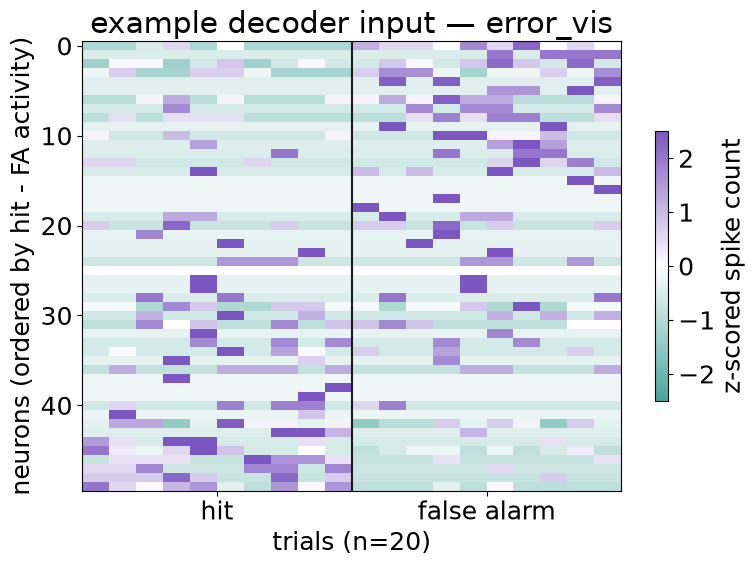

In [124]:
# Example population activity fed into the decoder (neurons x trials), z-scored
# per neuron -- i.e. essentially what the StandardScaler + LinearSVC sees.
from module import _BLOCK_STIM, _subsample_mask

plt.rcParams.update({'font.size': 18})
def decoder_input_matrix(decoder, mouse_id, region, random_state=0,
                         n_neurons=50, n_trials=10):
    """Rebuild the (trials x neurons) spike-count matrix that
    `decode_trial_identity` feeds to the SVM for one region-session, mirroring
    its unit / trial subsampling (seed `random_state`). Returns
    (count_array, labels, unit_ids, (rew_stim, unrew_stim))."""
    kw = DECODERS[decoder]['kwargs']
    block = kw['block']
    match_block = kw.get('match_block', True)
    rew_stim, unrew_stim = kw.get('stim_pair') or _BLOCK_STIM[block]
    if 'class_outcomes' in kw:
        outcome_a, outcome_b = kw['class_outcomes']
    elif kw.get('outcome_filter', 1) == 1:
        outcome_a, outcome_b = 'is_hit', 'is_false_alarm'
    else:
        outcome_a, outcome_b = None, None

    _nwb, units_s, trials_s = nwb_cache[mouse_id]
    rng = np.random.default_rng(random_state)

    region_units = units_s[units_s.default_qc & (units_s.structure == region)]
    region_units = region_units.iloc[
        np.sort(rng.choice(len(region_units), size=n_neurons, replace=False))]

    rew_mask = get_stim_times(trials_s, rew_stim, block, outcome_a,
                              match_block=match_block).to_numpy()
    unrew_mask = get_stim_times(trials_s, unrew_stim, block, outcome_b,
                                match_block=match_block).to_numpy()
    rew_mask = _subsample_mask(rew_mask, n_trials, rng)
    unrew_mask = _subsample_mask(unrew_mask, n_trials, rng)

    trial_mask = rew_mask | unrew_mask
    stim_times = trials_s.loc[trial_mask, 'stim_start_time'].to_numpy()
    labels = trials_s.loc[trial_mask, 'stim_name'].to_numpy()

    n_bins = len(DECODE_BIN_EDGES) - 1
    tensor = np.zeros((len(region_units), len(stim_times), n_bins))
    for i, spk in enumerate(region_units.spike_times.values):
        tensor[i] = get_binned_triggered_spike_counts_fast(
            spk, stim_times, DECODE_BIN_EDGES)
    count_array = tensor[:, :, WINDOW_BIN_SLICE].sum(axis=2).T   # (trials, neurons)
    return count_array, labels, region_units.index.to_numpy(), (rew_stim, unrew_stim)


# --- pick an example region-session (highest CV accuracy for the decoder) ---
EXAMPLE_DECODER = 'error_vis'
EXAMPLE_REGION = 'MOs'
_cand = ok_all[(ok_all.decoder == EXAMPLE_DECODER)
               & (ok_all.region == EXAMPLE_REGION)]
if not len(_cand):
    _cand = ok_all[ok_all.decoder == EXAMPLE_DECODER]
_ex = _cand.sort_values('cv_accuracy_mean', ascending=False).iloc[1]
EXAMPLE_MOUSE, EXAMPLE_REGION = _ex.mouse_id, _ex.region

X, labels, unit_ids, (rew_stim, unrew_stim) = decoder_input_matrix(
    EXAMPLE_DECODER, EXAMPLE_MOUSE, EXAMPLE_REGION)

# z-score each neuron across trials (the SVM's StandardScaler does the same,
# fit per training fold)
_sd = X.std(axis=0)
Z = (X - X.mean(axis=0)) / np.where(_sd > 0, _sd, 1.0)

# group trials by class (rewarded stim first); order neurons by (hit - FA)
t_order = np.argsort(labels != rew_stim, kind='stable')
Z, labels_o = Z[t_order], labels[t_order]
is_rew = labels_o == rew_stim
n_order = np.argsort(Z[is_rew].mean(axis=0) - Z[~is_rew].mean(axis=0))
Zt = Z[:, n_order].T                                            # (neurons, trials)

DIV_CMAP = mpl.colors.LinearSegmentedColormap.from_list(
    'div_teal_purple', [C_TEAL, '#ffffff', C_PURPLE])

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(Zt, aspect='auto', cmap=DIV_CMAP, vmin=-2.5, vmax=2.5,
               interpolation='nearest')
split = int(is_rew.sum())
ax.axvline(split - 0.5, color='0.1', lw=1.5)
ax.set_xticks([split / 2 - 0.5,
               split + (len(labels_o) - split) / 2 - 0.5])
ax.set_xticklabels(['hit', 'false alarm'])
ax.set_xlabel(f'trials (n={Zt.shape[1]})')
ax.set_ylabel(f'neurons (ordered by hit - FA activity)')
ax.set_title(f'example decoder input — {EXAMPLE_DECODER}')
cbar = fig.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label('z-scored spike count')
fig.tight_layout()
plt.show()


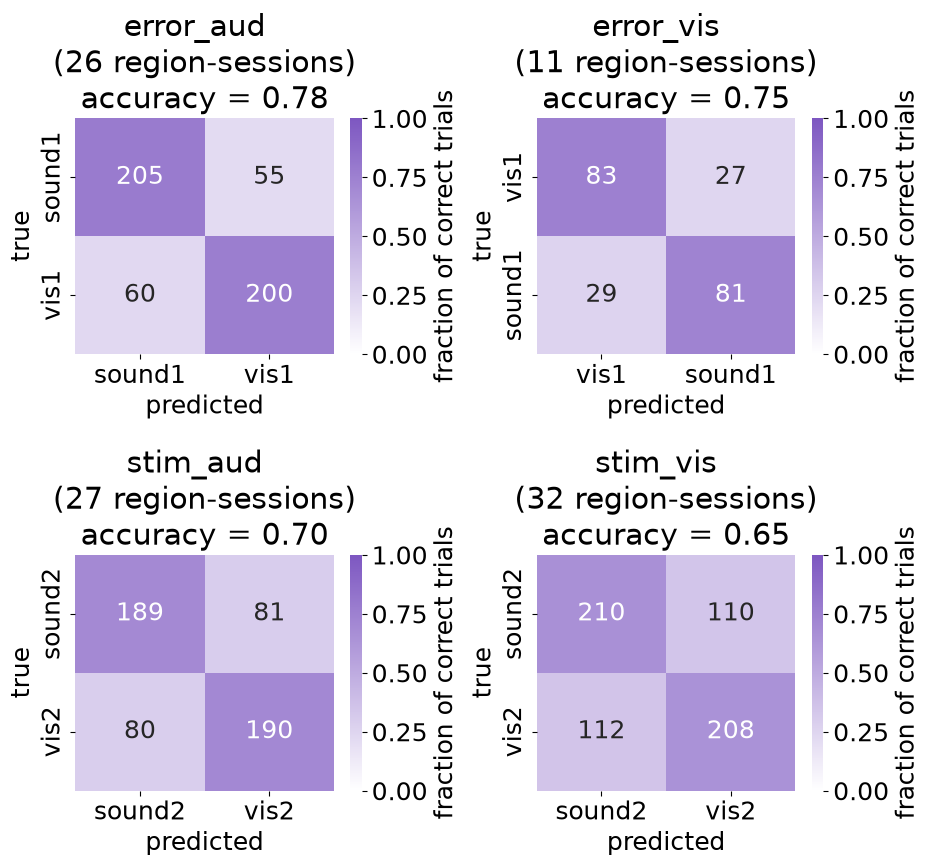

In [125]:
# Pooled confusion matrix for each of the four decoders (cross-validated
# predictions summed across all ok region-sessions, then row-normalised).
plt.rcParams.update({'font.size': 18})
fig, axes = plt.subplots(2, 2, figsize=(9.5, 9))

for ax, name in zip(axes.ravel(), DECODERS):
    g = ok_all[ok_all.decoder == name]
    if not len(g):
        ax.set_visible(False)
        continue
    labels = g['confusion_labels'].iloc[0]
    conf_total = np.sum(np.stack(g['confusion_matrix'].values), axis=0)
    conf_frac = conf_total / conf_total.sum(axis=1, keepdims=True)
    sns.heatmap(conf_frac, annot=conf_total, fmt='d', cmap=SEQ_CMAP,
                vmin=0, vmax=1, xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'fraction of correct trials'}, ax=ax)
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.set_title(f'{name}  \n({len(g)} region-sessions)\n'
                 f'accuracy = {np.diag(conf_total).sum() / conf_total.sum():.2f}')

fig.tight_layout()
plt.show()


## A conserved hit / false-alarm code? — decoder pooled across both blocks

The four decoders above are each trained *within* one block. This decoder is
trained on **hit vs false-alarm target trials pooled across the auditory and
the visual block**, to ask whether there is a single, block-invariant neural
code for the behavioural outcome (lick-to-go vs lick-to-nogo) that generalises
regardless of which modality is currently rewarded.

* classes are the **outcome** (`is_hit` vs `is_false_alarm`) on target trials,
  not the stimulus — so `sound1` and `vis1` appear in *both* classes,
* trials are **balanced by block**: each of the four block × outcome cells
  (aud-hit, vis-hit, aud-FA, vis-FA) contributes the same number of trials, so
  block cannot be used as a shortcut,
* run on the regions kept for *both* per-block error decoders
  (`keep['error_aud'] ∩ keep['error_vis']`), on the same 50-unit default-QC
  subsample and the same decode window as Pass 2,
* chance is the label-shuffle null (`N_PERM` permutations), feature importance
  the same repeated-split `weight_stability` as the other decoders.

In [87]:
# --- Pooled hit vs false-alarm decoder (both blocks, block-balanced) --------
from module import _repeated_split_importance, _make_svc
from sklearn.model_selection import cross_val_score, cross_val_predict, permutation_test_score

POOLED_MIN_PER_CELL = 8       # min trials in each block x outcome cell
POOLED_SEED = 0

pooled_keep = sorted(set(keep['error_aud']) & set(keep['error_vis']))
pooled_todo = scan[scan.meets_error_aud & scan.meets_error_vis
                   & scan.region.isin(pooled_keep)]
print(f"pooled decoder: {len(pooled_todo)} region-sessions "
      f"({pooled_todo.mouse_id.nunique()} mice, "
      f"regions {sorted(pooled_todo.region.unique())})")

_n_bins = len(DECODE_BIN_EDGES) - 1
_win_start = WINDOW_BIN_SLICE.start or 0
_win_stop = WINDOW_BIN_SLICE.stop if WINDOW_BIN_SLICE.stop is not None else _n_bins
_win_dur = float(DECODE_BIN_EDGES[_win_stop] - DECODE_BIN_EDGES[_win_start])
POOLED_CLASSES = np.array(['hit', 'false_alarm'])

pooled_rows = []
for (subject_id, region), _ in tqdm(list(pooled_todo.groupby(['mouse_id', 'region'])),
                                    desc="pooled", unit="region-session"):
    _nwb, units_s, trials_s = nwb_cache[subject_id]

    # units: default QC in region, same 50-unit subsample as the other decoders
    region_units = units_s[units_s.default_qc & (units_s.structure == region)]
    if len(region_units) < MIN_UNITS:
        continue
    u_rng = np.random.default_rng(POOLED_SEED)
    u_pick = np.sort(u_rng.choice(len(region_units), size=50, replace=False))
    region_units = region_units.iloc[u_pick]

    # trials: hit / FA target trials in each block, then balance the 4 cells
    onset = trials_s.stim_start_time.to_numpy()
    is_tgt = trials_s.is_target.to_numpy()
    blk = trials_s.rewarded_modality.to_numpy()
    is_hit = trials_s.is_hit.to_numpy()
    is_fa = trials_s.is_false_alarm.to_numpy()
    cells = {
        ('hit', 'aud'): np.flatnonzero(is_tgt & is_hit & (blk == 'aud')),
        ('hit', 'vis'): np.flatnonzero(is_tgt & is_hit & (blk == 'vis')),
        ('false_alarm', 'aud'): np.flatnonzero(is_tgt & is_fa & (blk == 'aud')),
        ('false_alarm', 'vis'): np.flatnonzero(is_tgt & is_fa & (blk == 'vis')),
    }
    n_per_cell = min(len(v) for v in cells.values())
    if n_per_cell < POOLED_MIN_PER_CELL:
        continue
    t_rng = np.random.default_rng(POOLED_SEED)
    sel_idx, sel_label = [], []
    for (outcome, _b), idx in cells.items():
        sel_idx.append(t_rng.choice(idx, size=n_per_cell, replace=False))
        sel_label += [outcome] * n_per_cell
    sel_idx = np.concatenate(sel_idx)
    label_array = np.array(sel_label)
    stim_times = onset[sel_idx]

    # population spike-count matrix (trials x neurons) over the decode window;
    # _make_svc z-scores each neuron (StandardScaler) before the SVM
    tensor = np.zeros((len(region_units), len(stim_times), _n_bins))
    for row, spk in enumerate(region_units.spike_times.values):
        tensor[row] = get_binned_triggered_spike_counts_fast(
            spk, stim_times, DECODE_BIN_EDGES)
    count_array = np.sum(tensor[:, :, WINDOW_BIN_SLICE], axis=2).T
    rate_array = count_array / _win_dur

    x_tr, x_te, y_tr, y_te = train_test_split(
        count_array, label_array, random_state=POOLED_SEED, stratify=label_array)
    svc = _make_svc(5000, POOLED_SEED).fit(x_tr, y_tr)
    cv_scores = cross_val_score(
        _make_svc(5000, POOLED_SEED),
        count_array, label_array, cv=5)
    cv_pred = cross_val_predict(
        _make_svc(5000, POOLED_SEED),
        count_array, label_array, cv=5)
    _, null_scores, perm_p = permutation_test_score(
        _make_svc(5000, POOLED_SEED),
        count_array, label_array, cv=5, n_permutations=N_PERM,
        random_state=POOLED_SEED, n_jobs=-1)
    imp = _repeated_split_importance(
        count_array, rate_array, label_array,
        rew_stim='hit', unrew_stim='false_alarm',
        n_repeats=N_IMPORTANCE_REPEATS, top_frac=IMPORTANCE_TOP_FRAC,
        test_size=0.25, max_iter=5000, random_state=POOLED_SEED)

    pooled_rows.append(dict(
        mouse_id=subject_id, region=region, block='both',
        decoder='error_pooled', family='error_pooled', status='ok',
        n_units=len(region_units), n_trials=len(label_array),
        n_per_cell=int(n_per_cell),
        split_accuracy=svc.score(x_te, y_te),
        cv_accuracy_mean=float(cv_scores.mean()), cv_accuracy_folds=cv_scores,
        chance=float(null_scores.mean()),
        chance_std=float(null_scores.std(ddof=1)), chance_p=float(perm_p),
        null_accuracy=null_scores,
        confusion_matrix=confusion_matrix(label_array, cv_pred, labels=POOLED_CLASSES),
        confusion_labels=list(POOLED_CLASSES),
        unit_ids=region_units.index.to_numpy(), **imp))
    tqdm.write(f"  {subject_id} {region:<5} cv {cv_scores.mean():.2f} "
               f"(chance {null_scores.mean():.2f} +/- {null_scores.std(ddof=1):.2f}, "
               f"p {perm_p:.3f}; {n_per_cell}/cell)")

pooled_results = pd.DataFrame(pooled_rows)
pooled_ok = pooled_results[pooled_results.status == 'ok'].copy()

# per-neuron importance table for the pooled decoder (same shape as unit_importance)
pooled_unit_importance = pd.DataFrame([
    dict(decoder='error_pooled', family='error_pooled', block='both',
         mouse_id=r.mouse_id, region=r.region, unit_id=int(uid),
         weight_stability=float(r.weight_stability[j]),
         weight_abs_mean=float(r.weight_abs_mean[j]),
         single_unit_stat=float(r.single_unit_stat[j]),
         n_stat_reps=int(r.single_unit_stat_n_reps[j]))
    for r in pooled_ok.itertuples() for j, uid in enumerate(r.unit_ids)
])
print(f"\npooled decoder: {len(pooled_ok)} region-sessions, "
      f"{len(pooled_unit_importance)} unit rows")
pooled_ok[['mouse_id', 'region', 'n_per_cell', 'n_trials',
           'cv_accuracy_mean', 'chance', 'chance_p']]


pooled decoder: 11 region-sessions (6 mice, regions ['MOp', 'MOs', 'SSp'])


pooled:   9%|▉         | 1/11 [00:01<00:16,  1.67s/region-session]

  664851 MOs   cv 0.59 (chance 0.51 +/- 0.08, p 0.144; 14/cell)


pooled:  18%|█▊        | 2/11 [00:03<00:15,  1.70s/region-session]

  667252 MOp   cv 0.72 (chance 0.51 +/- 0.07, p 0.010; 15/cell)


...

pooled:  91%|█████████ | 10/11 [00:17<00:01,  1.74s/region-session]

  742903 SSp   cv 0.59 (chance 0.50 +/- 0.08, p 0.174; 11/cell)


pooled: 100%|██████████| 11/11 [00:19<00:00,  1.74s/region-session]

  743199 MOs   cv 0.70 (chance 0.50 +/- 0.08, p 0.010; 10/cell)

pooled decoder: 11 region-sessions, 550 unit rows


,mouse_id,region,n_per_cell,n_trials,cv_accuracy_mean,chance,chance_p
0,664851,MOs,14,56,0.590909,0.506924,0.144279
1,667252,MOp,15,60,0.716667,0.509750,0.009950
2,667252,MOs,15,60,0.716667,0.506750,0.009950
3,708016,MOp,11,44,0.727778,0.503542,0.004975
4,708016,MOs,11,44,0.608333,0.488458,0.099502
5,708016,SSp,11,44,0.591667,0.500611,0.159204
6,715710,MOs,18,72,0.652381,0.495762,0.019900
7,715710,SSp,18,72,0.472381,0.504543,0.716418
8,742903,MOp,11,44,0.472222,0.494667,0.631841
9,742903,SSp,11,44,0.591667,0.501792,0.174129


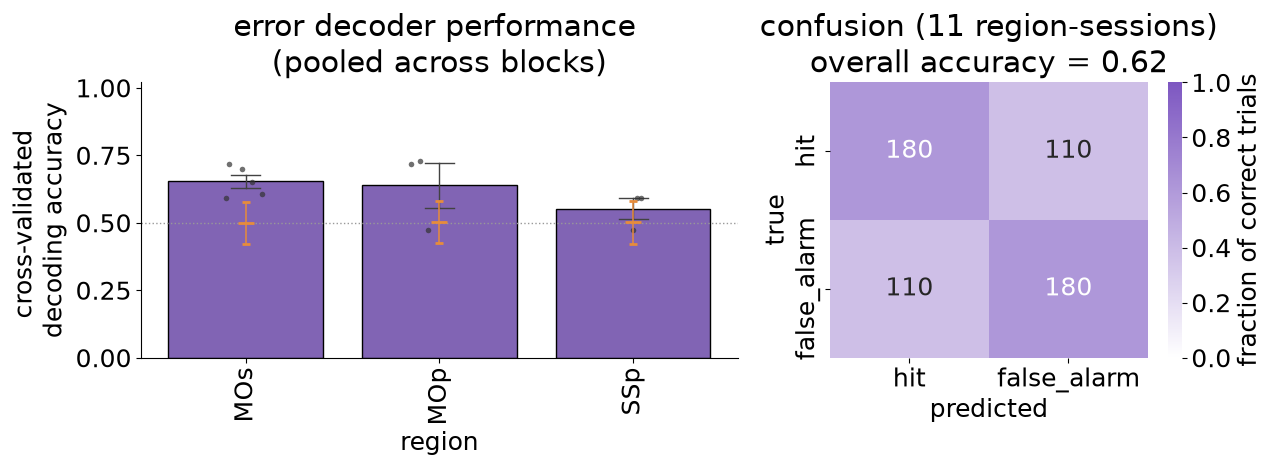

In [132]:
# Pooled hit-vs-FA decoder: accuracy by region + pooled confusion matrix.
plt.rcParams.update({'font.size': 18})
if len(pooled_ok):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                             gridspec_kw={'width_ratios': [1.5, 1]})

    d = pooled_ok.dropna(subset=['cv_accuracy_mean'])
    order = (d.groupby('region')['cv_accuracy_mean'].mean()
             .sort_values(ascending=False).index.tolist())
    sns.barplot(data=d, x='region', y='cv_accuracy_mean', order=order,
                color=C_PURPLE, edgecolor='black', errorbar='se',
                capsize=0.15, err_kws={'linewidth': 1.0}, ax=axes[0])
    sns.stripplot(data=d, x='region', y='cv_accuracy_mean', order=order,
                  color='0.2', size=4, jitter=0.15, alpha=0.7, ax=axes[0])
    for xi, region in enumerate(order):
        sub = d[d.region == region]
        axes[0].errorbar(xi, sub['chance'].mean(), yerr=sub['chance_std'].mean(),
                         fmt='_', color=C_ORANGE, markersize=12, markeredgewidth=2,
                         elinewidth=1.1, capsize=3, zorder=5)
    axes[0].axhline(0.5, ls=':', color='0.6', linewidth=1)
    axes[0].set_ylim(0, 1.02)
    axes[0].set_xlabel('region')
    axes[0].set_ylabel('cross-validated \ndecoding accuracy')
    axes[0].set_title('error decoder performance \n(pooled across blocks)')
    axes[0].tick_params(axis='x', rotation=90)
    sns.despine(ax=axes[0])

    conf = np.sum(np.stack(pooled_ok['confusion_matrix'].values), axis=0)
    conf_frac = conf / conf.sum(axis=1, keepdims=True)
    labels = pooled_ok['confusion_labels'].iloc[0]
    sns.heatmap(conf_frac, annot=conf, fmt='d', cmap=SEQ_CMAP, vmin=0, vmax=1,
                xticklabels=labels, yticklabels=labels, ax=axes[1],
                cbar_kws={'label': 'fraction of correct trials'})
    axes[1].set_xlabel('predicted')
    axes[1].set_ylabel('true')
    axes[1].set_title(f'confusion ({len(pooled_ok)} region-sessions)\n'
                      f'overall accuracy = {np.diag(conf).sum() / conf.sum():.2f}')

    fig.tight_layout()
    plt.show()
else:
    print("no region-session met the pooled-decoder criterion")


## Which neurons carry each decoder (feature importance)

For every decoder (all four: error / stim × aud / vis) each region-session is
fit `N_IMPORTANCE_REPEATS` times on independent stratified train/test splits.
In each repeat `r` we keep the weight vector `w_r`, score `accuracy_r` on the
held-out trials, and flag the top `IMPORTANCE_TOP_FRAC` of neurons by `|w_r|`
as "important".

Two per-neuron quantities come out of this:

* **`weight_stability`** — the fraction of repeats in which the neuron was
  flagged (`weight_abs_mean`, the mean `|w_r|` across repeats, is the
  continuous version).
* **`single_unit_stat`** — the circularity-safe firing-property estimate,
  computed **only on the held-out trials** of the repeats in which the neuron
  was both flagged and had test trials of both classes. For the **error**
  decoders it is `mean rate on hit trials − mean rate on false-alarm trials`;
  for the **stim** decoders it is `mean rate on sound2 − mean rate on vis2`.
  Selection (flagging) and measurement never use the same trials, so it is not
  inflated by selection bias.

Both quantities are collected into the `unit_importance` table below, which
feeds the error-exclusive comparison in the next section.


In [89]:
# Unpack the per-neuron importance arrays into one long table (one row per unit
# per region-session per decoder).
def unit_importance_table(ok_rows):
    out = []
    for _, r in ok_rows.iterrows():
        for j, uid in enumerate(r['unit_ids']):
            out.append(dict(
                decoder=r['decoder'],
                family=r['family'],
                block=r['block'],
                mouse_id=r['mouse_id'],
                region=r['region'],
                unit_id=int(uid),
                weight_stability=float(r['weight_stability'][j]),
                weight_abs_mean=float(r['weight_abs_mean'][j]),
                single_unit_stat=float(r['single_unit_stat'][j]),
                n_stat_reps=int(r['single_unit_stat_n_reps'][j]),
            ))
    return pd.DataFrame(out)

unit_importance = unit_importance_table(ok_all)

n_flag_frac = (ok_all['n_flagged_per_rep'].iloc[0]
               / len(ok_all['weight_stability'].iloc[0]))
for name, g in unit_importance.groupby('decoder'):
    n_rs = g.groupby(['mouse_id', 'region']).ngroups
    print(f"{name:<10}: {len(g)} units across {n_rs} region-sessions")
print(f"~{n_flag_frac:.0%} of neurons flagged per repeat (chance stability)")

unit_importance.sort_values('weight_stability', ascending=False).head(15)


error_aud : 1300 units across 26 region-sessions
error_vis : 550 units across 11 region-sessions
stim_aud  : 1350 units across 27 region-sessions
stim_vis  : 1600 units across 32 region-sessions
~10% of neurons flagged per repeat (chance stability)


,decoder,family,block,mouse_id,region,unit_id,weight_stability,weight_abs_mean,single_unit_stat,n_stat_reps
524,error_aud,error,aud,714748,PL,1001,1.0,0.153358,-21.166667,100
3660,stim_vis,stim,vis,713655,MOp,236,1.0,0.215283,-6.850000,100
2473,stim_aud,stim,aud,714748,ORBl,587,1.0,0.193863,-26.416667,100
3802,stim_vis,stim,vis,714748,MOs,612,1.0,0.232085,-9.350000,100
3788,stim_vis,stim,vis,713655,SSs,701,1.0,0.282601,-8.533333,100
3105,stim_aud,stim,aud,759434,MOs,1435,1.0,0.229367,-7.141667,100
137,error_aud,error,aud,664851,PL,1456,1.0,0.230503,-22.125000,100
2256,stim_aud,stim,aud,713655,MOp,158,1.0,0.213583,15.666667,100
3250,stim_vis,stim,vis,664851,MOs,98,1.0,0.191331,19.708333,100
3302,stim_vis,stim,vis,664851,PL,1166,1.0,0.206062,-16.583333,100


## Error-exclusive neurons: error decoder vs stim decoder, within each block

Within a block the error and stim decoders are run on the same region-sessions
and the same 50-unit subsample, so each unit has two `weight_stability`
scores:

* **error decoder** — target hit vs distractor false alarm (stimulus identity
  *and* lick / error signal),
* **stim decoder** — sound2 vs vis2 on correct-reject trials (stimulus
  identity only, lick withheld).

A unit that is a stable feature of the error decoder but *not* of the stim
decoder carries the lick / error signal rather than stimulus identity. We flag
those as **error-exclusive**: `stability(error) >= HIGH` and
`stability(stim) <= LOW`. This is computed separately for the auditory and the
visual block, and then compared across the two blocks.

[aud] 1050 units decoded by BOTH families (6 regions, 8 mice)  |  error-exclusive 25  stim-exclusive 19  shared-stable 3
[vis] 550 units decoded by BOTH families (3 regions, 6 mice)  |  error-exclusive 12  stim-exclusive 7  shared-stable 1


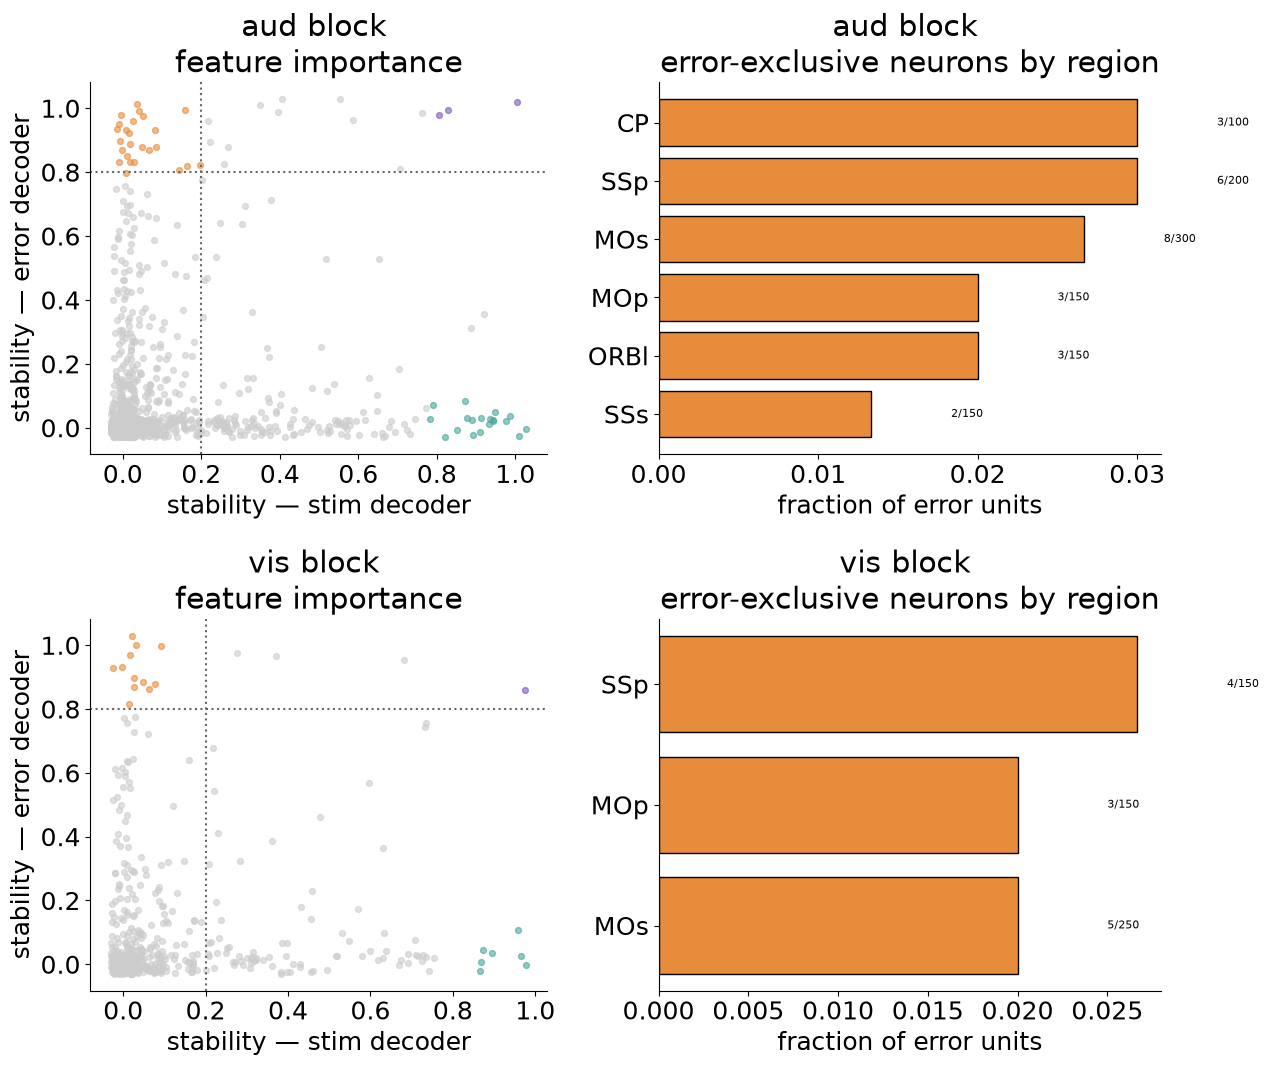

In [165]:
# Match units across the error and stim decoders on (mouse, region, unit_id),
# separately within each block.
HIGH = 0.8      # "stable feature" threshold
LOW = 0.2       # "not a feature" threshold

plt.rcParams.update({'font.size': 18})
def compare_families(block):
    e = unit_importance[(unit_importance.family == 'error')
                        & (unit_importance.block == block)]
    s = unit_importance[(unit_importance.family == 'stim')
                        & (unit_importance.block == block)]
    c = e.merge(s, on=['mouse_id', 'region', 'unit_id'],
                suffixes=('_error', '_stim'))
    c['block'] = block
    c['error_exclusive'] = ((c.weight_stability_error >= HIGH)
                            & (c.weight_stability_stim <= LOW))
    c['stim_exclusive'] = ((c.weight_stability_stim >= HIGH)
                           & (c.weight_stability_error <= LOW))
    c['shared'] = ((c.weight_stability_error >= HIGH)
                   & (c.weight_stability_stim >= HIGH))
    c['group'] = np.select(
        [c.error_exclusive, c.stim_exclusive, c.shared],
        ['error_exclusive', 'stim_exclusive', 'shared'], default='other')
    return c

cmp = pd.concat([compare_families('aud'), compare_families('vis')],
                ignore_index=True)

for blk in BLOCK_ORDER:
    b = cmp[cmp.block == blk]
    print(f"[{blk}] {len(b)} units decoded by BOTH families "
          f"({b.region.nunique()} regions, {b.mouse_id.nunique()} mice)  |  "
          f"error-exclusive {int(b.error_exclusive.sum())}  "
          f"stim-exclusive {int(b.stim_exclusive.sum())}  "
          f"shared-stable {int(b.shared.sum())}")

# GROUP_PAL comes from the shared colour-scheme cell
jit = lambda v: v + np.random.uniform(-0.03, 0.03, len(v))

fig, axes = plt.subplots(2, 2, figsize=(13, 11),
                         gridspec_kw={'width_ratios': [1, 1.1]})

for row, blk in enumerate(BLOCK_ORDER):
    b = cmp[cmp.block == blk]

    # left: stability(stim) vs stability(error)
    ax = axes[row, 0]
    for g, sub in b.groupby('group'):
        ax.scatter(jit(sub.weight_stability_stim), jit(sub.weight_stability_error),
                   s=18, alpha=0.6, color=GROUP_PAL[g], label=f'{g} (n={len(sub)})')
    ax.axvline(LOW, ls=':', color='0.4')
    ax.axhline(HIGH, ls=':', color='0.4')
    ax.set_xlabel('stability — stim decoder')
    ax.set_ylabel('stability — error decoder')
    ax.set_title(f'{blk} block \nfeature importance')
    # ax.legend(frameon=False, fontsize=8)
    sns.despine(ax=ax)

    # right: error-exclusive fraction per region
    ax = axes[row, 1]
    by_region = (b.groupby('region')
                 .agg(n_both=('unit_id', 'size'),
                      n_error_excl=('error_exclusive', 'sum'))
                 .assign(frac=lambda d: d.n_error_excl / d.n_both)
                 .sort_values('frac', ascending=False))
    ax.barh(by_region.index, by_region.frac, color=C_ORANGE, edgecolor='black')
    for yi, (reg, r) in enumerate(by_region.iterrows()):
        ax.text(r.frac + 0.005, yi, f"{int(r.n_error_excl)}/{int(r.n_both)}",
                va='center', fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('fraction of error units')
    ax.set_title(f'{blk} block \nerror-exclusive neurons by region')
    sns.despine(ax=ax)

fig.tight_layout()
plt.show()


37 error-exclusive units (stability_error >= 0.8, stability_stim <= 0.2)

500 units decoded in BOTH blocks (3 regions, 5 mice)
error-decoding (stability_error >= 0.8) in both blocks: 1  |  aud only: 18  |  vis only: 14


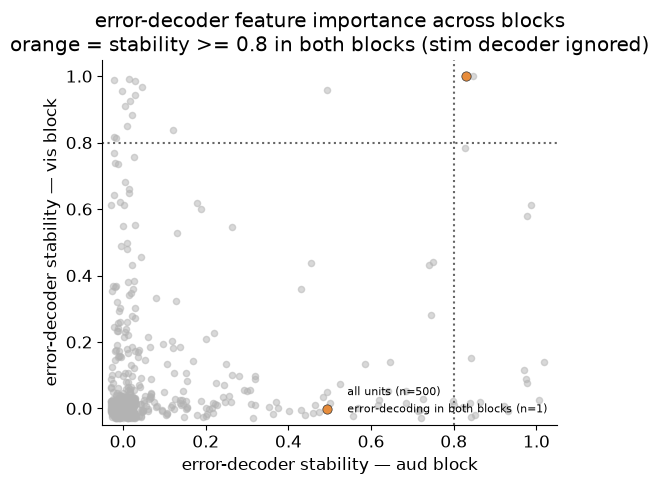

,mouse_id,region,unit_id,weight_stability_error_aud,weight_stability_error_vis,weight_stability_stim_aud,weight_stability_stim_vis,single_unit_stat_error_aud,single_unit_stat_error_vis
0,708016,MOs,105,0.82,0.99,0.0,0.38,1.01626,-15.715488


In [91]:
# The error-exclusive neurons in each block, with their held-out firing stats.
#   single_unit_stat_error : held-out (hit - FA)      rate diff (Hz)
#   single_unit_stat_stim  : held-out (sound2 - vis2) rate diff (Hz)
error_exclusive = (
    cmp.loc[cmp.error_exclusive,
            ['block', 'mouse_id', 'region', 'unit_id',
             'weight_stability_error', 'weight_stability_stim',
             'single_unit_stat_error', 'n_stat_reps_error',
             'single_unit_stat_stim', 'n_stat_reps_stim']]
    .sort_values(['block', 'region', 'weight_stability_error'],
                 ascending=[True, True, False])
    .reset_index(drop=True))
print(f"{len(error_exclusive)} error-exclusive units "
      f"(stability_error >= {HIGH}, stability_stim <= {LOW})")

# --- across-block comparison: units tested in BOTH blocks -----------------
# (a unit is tested in both blocks only if its region-session met all four
#  decoders' criteria)
both = cmp[cmp.block == 'aud'].merge(
    cmp[cmp.block == 'vis'], on=['mouse_id', 'region', 'unit_id'],
    suffixes=('_aud', '_vis'))
print(f"\n{len(both)} units decoded in BOTH blocks "
      f"({both.region.nunique()} regions, {both.mouse_id.nunique()} mice)")

# FINAL PLOT: highlight every neuron that carries the ERROR decoder in both
# blocks (weight_stability_error >= HIGH in aud AND vis), regardless of what
# the stim decoder did for that neuron.
both['error_both_blocks'] = ((both.weight_stability_error_aud >= HIGH)
                             & (both.weight_stability_error_vis >= HIGH))
error_decoding_both_blocks = (
    both.loc[both.error_both_blocks,
             ['mouse_id', 'region', 'unit_id',
              'weight_stability_error_aud', 'weight_stability_error_vis',
              'weight_stability_stim_aud', 'weight_stability_stim_vis',
              'single_unit_stat_error_aud', 'single_unit_stat_error_vis']]
    .sort_values(['region', 'mouse_id']).reset_index(drop=True))

n_both = int(both.error_both_blocks.sum())
n_aud_only = int(((both.weight_stability_error_aud >= HIGH)
                  & (both.weight_stability_error_vis < HIGH)).sum())
n_vis_only = int(((both.weight_stability_error_aud < HIGH)
                  & (both.weight_stability_error_vis >= HIGH)).sum())
print(f"error-decoding (stability_error >= {HIGH}) in both blocks: {n_both}  |  "
      f"aud only: {n_aud_only}  |  vis only: {n_vis_only}")

if len(both):
    fig, ax = plt.subplots(figsize=(5.5, 5))
    ax.scatter(jit(both.weight_stability_error_aud.values),
               jit(both.weight_stability_error_vis.values),
               s=20, alpha=0.5, color='0.7', label=f'all units (n={len(both)})')
    hi = both[both.error_both_blocks]
    ax.scatter(jit(hi.weight_stability_error_aud.values),
               jit(hi.weight_stability_error_vis.values),
               s=45, color=C_ORANGE, edgecolor='0.2', linewidth=0.5,
               label=f'error-decoding in both blocks (n={len(hi)})')
    ax.axvline(HIGH, ls=':', color='0.4')
    ax.axhline(HIGH, ls=':', color='0.4')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('error-decoder stability — aud block')
    ax.set_ylabel('error-decoder stability — vis block')
    ax.set_title('error-decoder feature importance across blocks\n'
                 f'orange = stability >= {HIGH} in both blocks (stim decoder ignored)')
    ax.legend(frameon=False, fontsize=8, loc='lower right')
    sns.despine(ax=ax)
    fig.tight_layout()
    plt.show()

error_decoding_both_blocks


## Pulling out the error-exclusive units

For a chosen error decoder (`error_aud` or `error_vis`) this picks the
region-session with the most **error-exclusive** units — units that are a
stable feature of the error decoder but *not* of the stim decoder
(`weight_stability_error >= HIGH` and `weight_stability_stim <= LOW`, taken
from `cmp` in the section above).

`qc_units_table` is that session's `nwbfile.units.to_dataframe()` subset that
fed the error decoder (default-QC units in the region, after the 50-unit
subsample), with the feature-importance columns joined on — `weight_stability`
from the error decoder plus `weight_stability_stim` / `single_unit_stat_stim`
from the stim decoder. `high_fi_units` restricts it to the error-exclusive
units and `high_fi_ids` are their NWB unit ids.

`qc_units_table_for(decoder, mouse_id, region)` builds the table for any
region-session; `all_unit_importance` is the long importance table across every
decoder.


In [161]:
# Error-exclusive units for one region-session --------------------------
# "error-exclusive" = a stable feature of the error decoder but NOT of the stim
# decoder: weight_stability(error) >= HIGH and weight_stability(stim) <= LOW
# (flagged per block in `cmp`, built in the section above). Only error_aud /
# error_vis have a stim-decoder counterpart, so error_pooled is not used here.
HIGH_FI_STABILITY = HIGH

# every decoder's per-neuron importance in one long table
all_unit_importance = pd.concat(
    [unit_importance, pooled_unit_importance], ignore_index=True) \
    if len(pooled_unit_importance) else unit_importance.copy()

# every decoder's row-level result (has unit_ids + the importance arrays)
_all_ok = pd.concat([ok_all, pooled_ok], ignore_index=True) \
    if len(pooled_ok) else ok_all.copy()


def qc_units_table_for(decoder, mouse_id, region):
    """Subset of this session's units.to_dataframe() that fed `decoder` in this
    region-session, indexed by NWB unit id, with the feature-importance columns
    (weight_stability, weight_abs_mean, single_unit_stat) joined on."""
    r = _all_ok[(_all_ok.decoder == decoder) & (_all_ok.mouse_id == mouse_id)
                & (_all_ok.region == region)]
    if not len(r):
        raise KeyError(f"no {decoder} result for mouse {mouse_id}, region {region}")
    r = r.iloc[0]
    units_df = nwb_cache[mouse_id][1]                 # full units.to_dataframe()
    tbl = units_df.loc[r['unit_ids']].copy()
    tbl['weight_stability'] = np.asarray(r['weight_stability'])
    tbl['weight_abs_mean'] = np.asarray(r['weight_abs_mean'])
    tbl['single_unit_stat'] = np.asarray(r['single_unit_stat'])
    tbl['decoder'] = decoder
    return tbl


FI_DECODER = 'error_aud'                       # 'error_aud' or 'error_vis'
FI_BLOCK = {'error_aud': 'aud', 'error_vis': 'vis'}[FI_DECODER]

# error-exclusive units in this block (from the error-vs-stim comparison `cmp`)
ee = cmp[(cmp.block == FI_BLOCK) & cmp.error_exclusive]

# rank region-sessions by how many error-exclusive units they have
_rank = (ee.groupby(['mouse_id', 'region']).size()
         .sort_values(ascending=False))
if not len(_rank):
    raise ValueError(f"no error-exclusive units in the {FI_BLOCK} block")
print(f"error-exclusive units per region-session ({FI_DECODER}):")
print(_rank.head(10).to_string())

FI_MOUSE, FI_REGION = _rank.index[0]           # use .index[k] to pick another
print(f"\nexample -> decoder {FI_DECODER}, mouse {FI_MOUSE}, region {FI_REGION}")

# the 50 QC units that fed the error decoder for this region-session ...
qc_units_table = qc_units_table_for(FI_DECODER, FI_MOUSE, FI_REGION)
# ... with the stim-decoder stability joined on, then restricted to the
# error-exclusive units
_ee_rs = (ee.loc[(ee.mouse_id == FI_MOUSE) & (ee.region == FI_REGION),
                 ['unit_id', 'weight_stability_stim', 'single_unit_stat_stim']]
          .set_index('unit_id'))
qc_units_table = qc_units_table.join(_ee_rs, how='left')

high_fi_units = qc_units_table.loc[qc_units_table.index.isin(_ee_rs.index)]
high_fi_ids = high_fi_units.index              # NWB unit ids to carry forward

print(f"\n{len(qc_units_table)} QC units fed the {FI_DECODER} decoder; "
      f"{len(high_fi_ids)} are error-exclusive "
      f"(weight_stability_error >= {HIGH}, weight_stability_stim <= {LOW})")
print("error-exclusive unit ids:", list(high_fi_ids))

high_fi_units[['structure', 'weight_stability', 'weight_stability_stim',
               'weight_abs_mean', 'single_unit_stat', 'single_unit_stat_stim',
               'firing_rate', 'presence_ratio', 'isi_violations_ratio',
               'cluster_id']].sort_values('weight_stability', ascending=False)


error-exclusive units per region-session (error_aud):
mouse_id  region
667252    MOs       3
742903    SSp       3
664851    MOs       2
662892    ORBl      2
742903    CP        2
759434    SSp       2
742903    MOp       2
708016    MOp       1
715710    MOs       1
714748    ORBl      1

example -> decoder error_aud, mouse 667252, region MOs

50 QC units fed the error_aud decoder; 3 are error-exclusive (weight_stability_error >= 0.8, weight_stability_stim <= 0.2)
error-exclusive unit ids: [74, 916, 962]


,structure,weight_stability,weight_stability_stim,weight_abs_mean,single_unit_stat,single_unit_stat_stim,firing_rate,presence_ratio,isi_violations_ratio,cluster_id
id,,,,,,,,,,
962,MOs,1.00,0.18,0.239600,-38.866667,17.268519,16.785121,1.0,0.002261,78
74,MOs,0.86,0.09,0.179090,-13.759690,10.185185,14.590559,1.0,0.014963,78
916,MOs,0.83,0.16,0.166949,7.399598,-1.145833,4.804350,1.0,0.021687,28


## Error-exclusive units — pooled (across-block) error decoder

The same as the section above, but for `error_pooled` — the hit-vs-false-alarm
decoder trained on both blocks at once. It has no single stim-decoder
counterpart, so each unit's pooled error-decoder stability is compared against
its stim-decoder stability in **each** block. A unit is **error-exclusive**
here when `weight_stability(error_pooled) >= HIGH` and its stim stability is
`<= LOW` in every block it was tested in (`weight_stability_stim_max <= LOW`).


In [141]:
# Error-exclusive units for the pooled (across-block) error decoder -----
if not len(pooled_unit_importance):
    raise ValueError("no region-session met the pooled-decoder criterion")

# error_pooled importance, renamed to the _error / _stim convention of `cmp`
_pool = pooled_unit_importance.rename(columns={
    'weight_stability': 'weight_stability_error',
    'weight_abs_mean': 'weight_abs_mean_error',
    'single_unit_stat': 'single_unit_stat_error',
    'n_stat_reps': 'n_stat_reps_error'})

# stim-decoder stability / stat per unit, widened to one column per block
_stim = unit_importance.loc[unit_importance.family == 'stim',
                            ['mouse_id', 'region', 'unit_id', 'block',
                             'weight_stability', 'single_unit_stat']]
_stim_w = _stim.pivot_table(index=['mouse_id', 'region', 'unit_id'],
                            columns='block',
                            values=['weight_stability', 'single_unit_stat'])
_stim_w.columns = [f'{v}_stim_{b}' for v, b in _stim_w.columns]
_stim_w = _stim_w.reset_index()

cmp_pooled = _pool.merge(_stim_w, on=['mouse_id', 'region', 'unit_id'],
                         how='inner')
_stim_stab_cols = [c for c in cmp_pooled.columns
                   if c.startswith('weight_stability_stim_')]
cmp_pooled['weight_stability_stim_max'] = cmp_pooled[_stim_stab_cols].max(axis=1)
cmp_pooled['error_exclusive'] = ((cmp_pooled.weight_stability_error >= HIGH)
                                 & (cmp_pooled.weight_stability_stim_max <= LOW))

# rank region-sessions by how many error-exclusive units they have
ee_pooled = cmp_pooled[cmp_pooled.error_exclusive]
_rank_pooled = (ee_pooled.groupby(['mouse_id', 'region']).size()
                .sort_values(ascending=False))
if not len(_rank_pooled):
    raise ValueError("no error-exclusive units for the pooled error decoder")
print("error-exclusive units per region-session (error_pooled):")
print(_rank_pooled.head(10).to_string())

POOL_MOUSE, POOL_REGION = _rank_pooled.index[0]   # use .index[k] to pick another
print(f"\nexample -> decoder error_pooled, mouse {POOL_MOUSE}, region {POOL_REGION}")

# the QC units that fed the pooled error decoder for this region-session ...
qc_units_table_pooled = qc_units_table_for('error_pooled', POOL_MOUSE, POOL_REGION)
# ... with the per-block stim-decoder columns joined on, then restricted to the
# error-exclusive units
_stim_join_cols = [c for c in ee_pooled.columns
                   if c.endswith(('_stim_aud', '_stim_vis'))] + \
                  ['weight_stability_stim_max']
_ee_rs = (ee_pooled.loc[(ee_pooled.mouse_id == POOL_MOUSE)
                        & (ee_pooled.region == POOL_REGION)]
          .set_index('unit_id')[_stim_join_cols])
qc_units_table_pooled = qc_units_table_pooled.join(_ee_rs, how='left')

high_fi_units_pooled = qc_units_table_pooled.loc[
    qc_units_table_pooled.index.isin(_ee_rs.index)]
high_fi_ids_pooled = high_fi_units_pooled.index   # NWB unit ids to carry forward

print(f"\n{len(qc_units_table_pooled)} QC units fed the error_pooled decoder; "
      f"{len(high_fi_ids_pooled)} are error-exclusive "
      f"(weight_stability_error >= {HIGH}, stim stability <= {LOW} in every "
      f"tested block)")
print("error-exclusive unit ids:", list(high_fi_ids_pooled))

_show = (['structure', 'weight_stability']
         + [c for c in ('weight_stability_stim_aud', 'weight_stability_stim_vis',
                        'weight_stability_stim_max')
            if c in high_fi_units_pooled.columns]
         + ['weight_abs_mean', 'single_unit_stat']
         + [c for c in ('single_unit_stat_stim_aud', 'single_unit_stat_stim_vis')
            if c in high_fi_units_pooled.columns]
         + ['firing_rate', 'presence_ratio', 'isi_violations_ratio', 'cluster_id'])
high_fi_units_pooled[_show].sort_values('weight_stability', ascending=False)


error-exclusive units per region-session (error_pooled):
mouse_id  region
664851    MOs       1
667252    MOp       1
          MOs       1
743199    MOs       1

example -> decoder error_pooled, mouse 664851, region MOs

50 QC units fed the error_pooled decoder; 1 are error-exclusive (weight_stability_error >= 0.8, stim stability <= 0.2 in every tested block)
error-exclusive unit ids: [1593]


,structure,weight_stability,weight_stability_stim_aud,weight_stability_stim_vis,weight_stability_stim_max,weight_abs_mean,single_unit_stat,single_unit_stat_stim_aud,single_unit_stat_stim_vis,firing_rate,presence_ratio,isi_violations_ratio,cluster_id
id,,,,,,,,,,,,,
1593,MOs,0.8,0.0,0.0,0.0,0.392535,4.669643,NaN,NaN,1.080982,0.981982,0.0,474


## Flip through the feature-importance neurons — hit vs false-alarm rasters

For a chosen decoder and region, `fi_neuron_table()` lists every
high-feature-importance neuron (`weight_stability >= HIGH_FI_STABILITY`), one
row per `(mouse, region, unit)`, sorted by stability.

`plot_fi_neuron(i)` draws neuron `i` from that table the way the example
figure is laid out: spike **rasters over a PSTH**, **hit** and **false-alarm**
target trials in each panel, **auditory block (left)** and **visual block
(right)** side by side. Trials are aligned to the **first lick**
(`trials.response_time`) by default — both hits and false alarms have a lick —
or pass `align='stim'` to align to stimulus onset.

`browse_fi_neurons()` wraps `plot_fi_neuron` in an `ipywidgets` slider when
that is available, so you can page through the neurons one at a time; set
`FI_BROWSE_REGION` to `'MOs'` (default) or any other region, and
`FI_BROWSE_DECODER` to any decoder in `all_unit_importance` (`'error_pooled'`,
`'error_aud'`, `'error_vis'`, `'stim_aud'`, `'stim_vis'`).


5 feature-importance neurons for error_pooled in MOs (weight_stability >= 0.8)
(ipywidgets unavailable — call plot_fi_neuron(i, table) to step through)


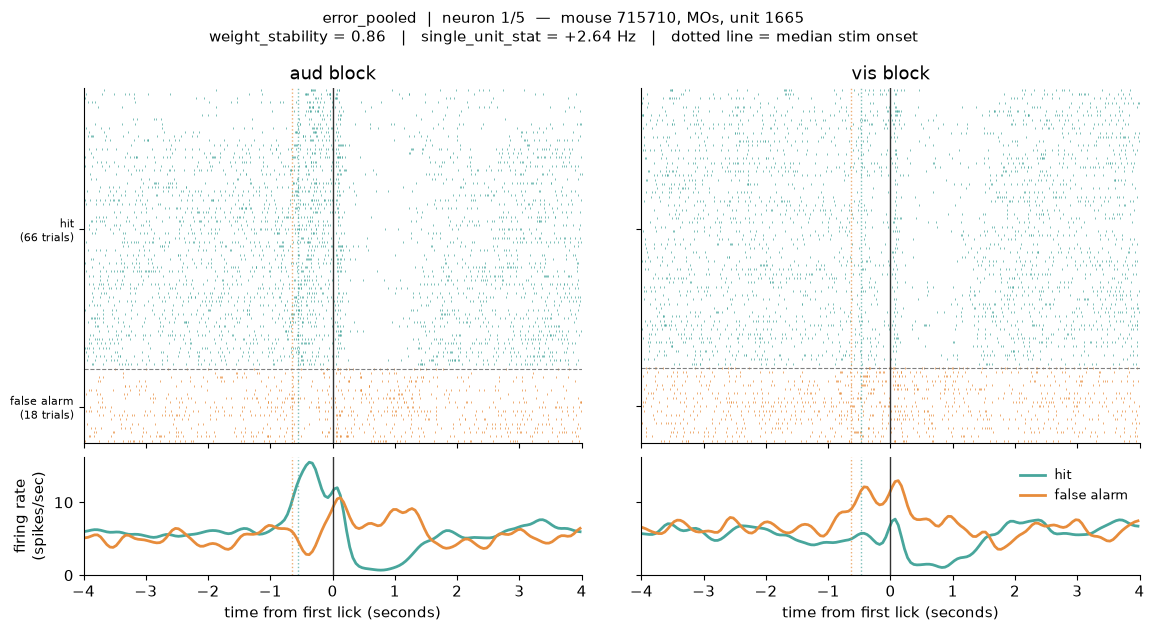

In [93]:
# Flip through feature-importance neurons: hit vs false-alarm rasters + PSTH,
# auditory and visual blocks side by side (see the example figure).
from scipy.ndimage import gaussian_filter1d

plt.rcParams.update({'font.size': 11})

# --- what to browse ----------------------------------------------------
FI_BROWSE_DECODER       = 'error_pooled'   # any decoder in all_unit_importance
FI_BROWSE_REGION        = 'MOs'            # region name, or None for all regions
FI_BROWSE_MIN_STABILITY = HIGH_FI_STABILITY

# --- raster / PSTH display settings -----------------------------------
RASTER_WINDOW_S  = (-4.0, 4.0)   # time shown around the alignment event
PSTH_BIN_S       = 0.05          # PSTH bin width
PSTH_SMOOTH_SIGMA_BINS = 2       # gaussian smoothing sigma, in bins
OUTCOME_PAL   = {'hit': C_TEAL, 'false_alarm': C_ORANGE}
OUTCOME_ORDER = ('hit', 'false_alarm')


def fi_neuron_table(decoder=None, region=None, min_stability=None):
    """High-feature-importance neurons for `decoder` (optionally restricted to
    one `region`), one row per (mouse, region, unit), sorted by weight_stability
    descending. Defaults come from the FI_BROWSE_* settings above."""
    decoder = FI_BROWSE_DECODER if decoder is None else decoder
    region = FI_BROWSE_REGION if region is None else region
    min_stability = (FI_BROWSE_MIN_STABILITY if min_stability is None
                     else min_stability)
    d = all_unit_importance[all_unit_importance.decoder == decoder]
    if region is not None:
        d = d[d.region == region]
    d = d[d.weight_stability >= min_stability]
    return (d[['mouse_id', 'region', 'unit_id', 'weight_stability',
               'weight_abs_mean', 'single_unit_stat']]
            .sort_values('weight_stability', ascending=False)
            .reset_index(drop=True))


def _align_event_times(trials, align):
    if align == 'stim':
        return trials.stim_start_time.to_numpy()
    if align == 'lick':
        return trials.response_time.to_numpy()
    raise ValueError("align must be 'lick' or 'stim'")


def plot_fi_neuron(i, table=None, align='lick', window=RASTER_WINDOW_S):
    """Draw feature-importance neuron `i` of `table` (default: fi_neuron_table()
    for the FI_BROWSE_* settings): hit vs false-alarm target trials, auditory
    block (left) and visual block (right), spike raster over the PSTH."""
    if table is None:
        table = fi_neuron_table()
    row = table.iloc[i]
    mouse_id, unit_id = row.mouse_id, int(row.unit_id)
    _nwb, units_s, trials_s = nwb_cache[mouse_id]
    spikes = np.asarray(units_s.loc[unit_id].spike_times)

    events = _align_event_times(trials_s, align)
    is_tgt = trials_s.is_target.to_numpy()
    block_of = trials_s.rewarded_modality.to_numpy()
    onset = trials_s.stim_start_time.to_numpy()
    outcome_mask = {'hit': trials_s.is_hit.to_numpy(),
                    'false_alarm': trials_s.is_false_alarm.to_numpy()}
    align_label = 'first lick' if align == 'lick' else 'stimulus onset'

    edges = np.arange(window[0], window[1] + 1e-9, PSTH_BIN_S)
    centers = edges[:-1] + PSTH_BIN_S / 2

    fig = plt.figure(figsize=(12, 6.5))
    gs = fig.add_gridspec(2, 2, height_ratios=[3, 1], hspace=0.06, wspace=0.12)
    psth_axes = []
    for col, block in enumerate(BLOCK_ORDER):
        ax_r = fig.add_subplot(gs[0, col])
        ax_p = fig.add_subplot(gs[1, col], sharex=ax_r)
        psth_axes.append(ax_p)

        y = 0
        yticks, yticklabels = [], []
        for outcome in OUTCOME_ORDER:
            sel = np.flatnonzero(is_tgt & (block_of == block)
                                 & outcome_mask[outcome] & np.isfinite(events))
            ev = events[sel]

            xs, ys = [], []
            for k, ev_t in enumerate(ev):
                rel = spikes - ev_t
                rel = rel[(rel >= window[0]) & (rel <= window[1])]
                xs.append(rel)
                ys.append(np.full(rel.size, y + k))
            if xs and sum(len(a) for a in xs):
                ax_r.scatter(np.concatenate(xs), np.concatenate(ys), s=3,
                             marker='|', linewidths=0.5,
                             color=OUTCOME_PAL[outcome])
            y += len(ev)
            yticks.append(y - len(ev) / 2)
            yticklabels.append(f'{outcome.replace("_", " ")}\n({len(ev)} trials)')

            # median timing of the *other* event (stim onset when aligned to
            # lick, and vice versa), as a thin dotted guide
            if len(ev):
                other = (onset[sel] - events[sel] if align == 'lick'
                         else events[sel] - onset[sel])
                other = other[np.isfinite(other)]
                if len(other):
                    for ax in (ax_r, ax_p):
                        ax.axvline(np.median(other), color=OUTCOME_PAL[outcome],
                                   ls=':', lw=1, alpha=0.7)

            if len(ev):
                counts = get_binned_triggered_spike_counts_fast(spikes, ev, edges)
                rate = gaussian_filter1d(counts.mean(axis=0) / PSTH_BIN_S,
                                         PSTH_SMOOTH_SIGMA_BINS)
                ax_p.plot(centers, rate, color=OUTCOME_PAL[outcome], lw=2,
                          label=outcome.replace('_', ' '))

        if 0 < yticks[0] * 2 < y:                      # hit / FA divider
            ax_r.axhline(yticks[0] * 2, color='0.5', ls='--', lw=0.8)
        ax_r.axvline(0, color='0.2', lw=1)
        ax_p.axvline(0, color='0.2', lw=1)
        ax_r.set_xlim(window)
        ax_r.set_ylim(-0.5, max(y, 1) - 0.5)
        ax_r.invert_yaxis()
        ax_r.set_yticks(yticks)
        ax_r.set_yticklabels(yticklabels, fontsize=8)
        ax_r.set_title(f'{block} block', fontsize=13)
        ax_r.tick_params(labelbottom=False)
        ax_p.set_xlabel(f'time from {align_label} (seconds)')
        if col == 0:
            ax_p.set_ylabel('firing rate\n(spikes/sec)')
        else:
            ax_r.tick_params(labelleft=False)
            ax_p.tick_params(labelleft=False)
        sns.despine(ax=ax_r)
        sns.despine(ax=ax_p)

    ymax = max(ax.get_ylim()[1] for ax in psth_axes)
    for ax in psth_axes:
        ax.set_ylim(0, ymax)
    psth_axes[-1].legend(frameon=False, fontsize=9, loc='upper right')

    fig.suptitle(
        f"{table.attrs.get('decoder', FI_BROWSE_DECODER)}  |  "
        f"neuron {i + 1}/{len(table)}  —  mouse {mouse_id}, {row.region}, "
        f"unit {unit_id}\nweight_stability = {row.weight_stability:.2f}   |   "
        f"single_unit_stat = {row.single_unit_stat:+.2f} Hz   |   "
        f"dotted line = median {'stim onset' if align == 'lick' else 'first lick'}",
        fontsize=11)
    fig.subplots_adjust(top=0.86, bottom=0.11, left=0.10, right=0.98)
    plt.show()


def browse_fi_neurons(decoder=None, region=None, align='lick'):
    """Page through the feature-importance neurons one at a time. Uses an
    ipywidgets slider when available, otherwise just plots the first neuron and
    you call plot_fi_neuron(i, table) yourself. Returns the neuron table."""
    table = fi_neuron_table(decoder, region)
    table.attrs['decoder'] = FI_BROWSE_DECODER if decoder is None else decoder
    tag = table.attrs['decoder'] + (f" in {region or FI_BROWSE_REGION}"
                                    if (region or FI_BROWSE_REGION) else "")
    print(f"{len(table)} feature-importance neurons for {tag} "
          f"(weight_stability >= {FI_BROWSE_MIN_STABILITY})")
    if not len(table):
        return table
    try:
        from ipywidgets import interact, IntSlider
        interact(lambda i: plot_fi_neuron(i, table, align=align),
                 i=IntSlider(min=0, max=len(table) - 1, step=1, value=0,
                             description='neuron'))
    except Exception:
        print("(ipywidgets unavailable — call plot_fi_neuron(i, table) to step "
              "through)")
        plot_fi_neuron(0, table, align=align)
    return table


fi_browse_table = browse_fi_neurons()


In [94]:
# =====================================================================
# SAVE RESULTS  --  written to /scratch
# ---------------------------------------------------------------------
# This writes to /scratch, which Code Ocean does NOT keep once the
# capsule stops (nor are the home directory or /code). Move anything
# worth keeping to ./results (a symlink to /results) before shutting
# the capsule down, or point run_dir back at /results.
#
# Written into /scratch/decode_across_mice_regions/<timestamp>/ :
#   results_raw.pkl        full Pass 2 DataFrame `results` (one row per
#                          region-session) WITH every numpy array column
#                          (null_accuracy, coef_weights, weight_stability,
#                          weight_abs_mean, single_unit_stat, unit_ids,
#                          confusion_matrix, cv_accuracy_folds, ...).
#                          Reload with pandas.read_pickle(...).
#   pass2_results.csv      the same table, array columns dropped (flat view)
#   pooled_results_raw.pkl / pooled_results.csv
#                          the pooled hit-vs-FA (both-blocks) decoder
#   session_metadata.csv   `df`
#   pass1_scan.csv         `scan`  (per mouse x region criterion)
#   unit_importance.csv    `all_unit_importance`  (one row per unit/decoder,
#                          incl. error_pooled)
#   family_comparison.csv  `cmp`  (error vs stim decoder, per unit)
#   error_exclusive.csv    `error_exclusive`
#   error_decoding_both_blocks.csv   units carrying the error decoder in both
#                                    blocks (final-plot highlight)
#   failed_sessions.csv    sessions the datacube mount would not serve
#   run_params.json        window, N_PERM, N_IMPORTANCE_REPEATS, thresholds, counts
#
# Figures are not saved here; add fig.savefig(run_dir / "name.png") if wanted.
# =====================================================================
import json, datetime, pathlib

_ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = pathlib.Path("/scratch/decode_across_mice_regions") / _ts
run_dir.mkdir(parents=True, exist_ok=True)

def _dump_csv(name, obj):
    if obj is None:
        return
    frame = obj if isinstance(obj, pd.DataFrame) else pd.DataFrame(obj)
    frame.to_csv(run_dir / name, index=False)
    print(f"  {name:<32} {len(frame):>5} rows")

def _flat(frame):
    arr_cols = [c for c in frame.columns
                if frame[c].map(lambda v: isinstance(v, (np.ndarray, list))).any()]
    return frame.drop(columns=arr_cols)

# --- full raw output (the expensive result), arrays preserved ---
results.to_pickle(run_dir / "results_raw.pkl")
print(f"  {'results_raw.pkl':<32} {len(results):>5} region-sessions  (pickle)")
_dump_csv("pass2_results.csv", _flat(results))

if len(pooled_results):
    pooled_results.to_pickle(run_dir / "pooled_results_raw.pkl")
    print(f"  {'pooled_results_raw.pkl':<32} {len(pooled_results):>5} region-sessions  (pickle)")
    _dump_csv("pooled_results.csv", _flat(pooled_results))

_dump_csv("session_metadata.csv", df)
_dump_csv("pass1_scan.csv", scan)
_dump_csv("unit_importance.csv", all_unit_importance)
_dump_csv("family_comparison.csv", cmp)
_dump_csv("error_exclusive.csv", error_exclusive)
_dump_csv("error_decoding_both_blocks.csv", error_decoding_both_blocks)
_dump_csv("failed_sessions.csv", pd.DataFrame(failed_sessions))

with open(run_dir / "run_params.json", "w") as _fh:
    json.dump(dict(
        run_local_time=_ts,
        DECODE_WINDOW_S=list(DECODE_WINDOW_S),
        WINDOW_BIN_SLICE=[WINDOW_BIN_SLICE.start, WINDOW_BIN_SLICE.stop],
        N_PERM=N_PERM,
        N_IMPORTANCE_REPEATS=N_IMPORTANCE_REPEATS,
        IMPORTANCE_TOP_FRAC=IMPORTANCE_TOP_FRAC,
        MIN_UNITS=MIN_UNITS,
        MIN_TRIALS_PER_CLASS=MIN_TRIALS_PER_CLASS,
        MIN_SESSIONS=MIN_SESSIONS,
        POOLED_MIN_PER_CELL=POOLED_MIN_PER_CELL,
        HIGH=HIGH, LOW=LOW,
        N_LOAD_RETRIES=N_LOAD_RETRIES,
        n_region_sessions=int(len(results)),
        n_ok=int((results.status == "ok").sum()),
        n_pooled_ok=int(len(pooled_ok)),
        n_failed_sessions=int(len(failed_sessions)),
    ), _fh, indent=2)
print(f"  {'run_params.json':<32}")

print(f"\nsaved to: {run_dir}")
print("(under /scratch -> NOT kept after the capsule shuts down; "
      "copy to ./results to persist)")


  results_raw.pkl                     96 region-sessions  (pickle)
  pass2_results.csv                   96 rows
  pooled_results_raw.pkl              11 region-sessions  (pickle)
  pooled_results.csv                  11 rows
  session_metadata.csv                12 rows
  pass1_scan.csv                     227 rows
  unit_importance.csv               5350 rows
  family_comparison.csv             1600 rows
  error_exclusive.csv                 37 rows
  error_decoding_both_blocks.csv       1 rows
  failed_sessions.csv                  0 rows
  run_params.json                 

saved to: /scratch/decode_across_mice_regions/20260903_191038
(under /scratch -> NOT kept after the capsule shuts down; copy to ./results to persist)
